<center><img src="images/logo_CESI.png" width="250"></center>

# <center><b>Projet algorithmique et optimisation combinatoire</b></center>
# <center><b>Livrable 1</b></center>

<p><center><b><u>Groupe de projet</u> :</b></center></p><br>
<center><b></b>Massa-Guidi Oumar Katiénin GBANÉ</center><br>
<center><b>Mickaël KING</b></center><br>
<center><b>Mohamed Lamine TRAORÉ</b></center><br>
<center><b>DORKENOO Ryan</b></center>

<p><center><b><u>Tuteur</u> : Mohamed Belgacem</b></center></p>
<p><center><b><u>Promotion</u> : FISE A3 Informatique</b></center></p>

# Sommaire

1. [Contexte](#1.-Contexte)
2. [Problématique](#2.-Problematique)
3. [Propriété théorique](#3.-Propriete-theorique)
4. [Contraintes](#4.-Contraintes)
    * a. [Fenêtres temporelles](#a.-Fenetres-temporelles)
    * b. [Flotte hétérogène](#b.-Flotte-heterogene)
    * c. [Trafic dynamique](#c.-Trafic-dynamique)
    * d. [Points de collecte](#.d-Points-de-collecte)
5. [Représentation des données](#5.-Representation-des-donnees)
    * a. [Modélisation sous forme de graphe](#a.-Modelisation-sous-forme-de-graphe)
    * b. [Modélisation de la contrainte de fenêtre temporelle](#b.-Modelisation-de-la-contrainte-de-fenetre-temporelle)
    * c. [Modélisation de la contrainte du traffic dynamique](#c.-Modelisation-de-la-contrainte-du-traffic-dynamique)
    * d. [Modélisation de la contrainte de points de collectes](#d.-Modelisation-de-la-contrainte-de-points-de-collectes)
    * e. [Modélisation de la contrainte de flotte hétérogène](#e.-Modelisation-de-la-contrainte-de-flotte-heterogene)
6. [Complexité du problème](#6.-Complexite-du-probleme)
7. [Modélisation mathématique finale](#7.-Modelisation-mathematique-finale)
    * a. [Objectif principal](#a.-Objectif-principal)
    * n. [Choix des contraintes](#b.-Choix-des-contraintes)
    * c. [Parametres d'entrees](#c.-Parametres-d'entrees)
    * d. [Variables de decisions](#d.-Variables-de-decisions)
    * e. [Fonction objective](#e.-Fonction-objective)
    * f. [Fonctions contraintes](#f.-Fonctions-contraintes)
    * g. [Calcul du CO2](#g.-Calcul-du-CO2)
8. [Solution informatique](#8.-Solution-informatique)
    * a. [Choix des algorithmes](#a.-Choix-des-algorithmes)
    * b. [Organisation (squelette) générale des codes](#b.-Organisation-(squelette)-generale-des-codes)
    * c. [Squelette du code CVRP](#c.-Squelette-du-code-CVRP)
    * d. [Squelette du code VRPTW](#d.-Squelette-du-code-VRPTW)
    * e. [Implémentation de la recherche Taboue](#e.-Implementation-de-la-recherche-Taboue)
    * f. [Implémentation de l'ALNS](#g.-Implementation-de-l'ALNS)
9. [Étude expérimentale](#9.-Etude-experimentale)
    * a. [Résultats avec recherche Taboue](#a.-Resultats-avec-recherche-Taboue)
    * b. [Implementation et Resultats avec recuit simule](#b.-Implementation-et-Resultats-avec-recuit-simule)
    * c. [Résultats avec ALNS](#c.-Resultats-avec-ALNS)
    * d. [Interprétation des résultats](#d.-Interpretation-des-resultats)
10. [Conclusion](#10.-Conclusion)
11. [Bibliographie](#11.-Bibliographie)

# 1. Contexte

L’ADEME cherche à développer de nouvelles solutions de mobilité afin de réduire l’impact environnemental des transports.

Dans ce cadre notre structure, CesiCDP met en place une équipe composée de quatre personnes pour concevoir une méthode d’optimisation de tournées de livraison intégrant certaines contraintes.

L’objectif est de proposer une solution efficace et durable permettant de réduire les émissions de $CO_2$ liées aux déplacements logistiques en optimisant des trajets plus court.

# 2. Problematique

Comment concevoir et mettre en œuvre une méthode de résolution efficace, robuste et scalable (capable de traiter plusieurs milliers de points) pour le problème de tournée de livraison sur réseau routier à temps dépendant, qui intègre des contraintes opérationnelles réalistes et qui, par son efficacité, permettra de réduire les durées de transport et l’impact environnemental associé ?

# 3. Propriete theorique

Nous allons utiliser <b>la théorie des graphes</b> pour modéliser notre problème. Pour cela, voyons quelques définitions 

<b>Un graphe</b> est un ensemble de <b>sommets</b> (ou nœuds). Certains sommets peuvent être reliés entre eux par des arêtes, on dit alors que ces sommets sont <b>adjacents</b>. Lorsqu'un sommet est relié à lui-même par une arête, cette arête est aussi appelée <b>une boucle</b>. 
On note souvent V l'ensemble des sommets de ce graphe, et E l'ensemble des arêtes.

On parle de <b>graphe orienté</b>, lorsque les arêtes sont <b>orientées</b> (les arêtes sont aussi appelées arcs dans ce cas). Sinon on parle de <b>graphe non-orienté</b>.

<b>Un arbre</b> est un <b>graphe connexe</b> sans <b>cycle</b>. Par exemple, une chaîne élémentaire est un arbre. 

Le problème de <b>l'Arbre Couvrant de Poids Minimum</b> (ACM) consiste à déterminer pour un graphe simple connexe, un arbre couvrant dont le poids des arêtes est minimum. Lorsque les arêtes ne sont pas pondérées, il s'agit simplement de trouver un arbre couvrant.
Il existe plusieurs algorithmes permettant de résoudre le problème de l'ACM (Kruska, Prim et Borůvka). 

<b>les Métaheuristiques</b>

Les métaheuristiques sont des cadres algorithmiques de haut niveau conçus pour trouver, avec un effort de calcul raisonnable, des solutions de bonne qualité (proches de l'optimal) à des problèmes d'optimisation combinatoire trop complexes (souvent NP-difficiles) pour être résolus exactement dans un temps acceptable.

Contrairement aux algorithmes exacts, elles ne garantissent pas de trouver la solution optimale, mais sont généralement plus rapides.
Le tableau suivant donne quelques exemples et une comparaison de quelques d'algorithme.

![image.png](attachment:image.png)



<b>Problèmes concrets modélisables par des graphes</b>

La théorie des graphes est un outil privilégié de modélisation et de résolution de problèmes dans un grand nombre de domaines allant de la science fondamentale aux applications technologiques concrètes. Les applications sont très nombreuses notamment les réseaux de transport au sens large (électriques, fluides, informatiques et télécommunications, véhicules),réseaux sociaux .

Le voyageur de commerce qui étant donné une liste de villes, et des distances entre toutes les paires de villes, détermine un plus court chemin qui visite chaque ville une et une seule fois et qui termine dans la ville de départ. Cela correspond à la recherche d'un cycle Hamiltonien, au cœur du prosit suivant (et on n'en dit pas plus, surtout sur l'aspect complexité).

Le Problème du Postier Chinois (PPC). <br>
Un facteur (le postier) doit partir de la poste, distribuer le courrier en parcourant toutes les rues (arêtes) de son secteur au moins une fois, puis revenir à son point de départ (la poste). Le facteur souhaite trouver l'itinéraire fermé le plus court possible pour minimiser la distance totale parcourue.




# 4. Contraintes



Pour rendre le problème plus réaliste et proche des situations industrielles, plusieurs contraintes peuvent être ajoutées au modèle de base du <b>problème de tournée de véhicules</b> (VRP – Vehicle Routing Problem).

Nous avons pour ce projet <b>4 contraintes</b> qui nous sont proposé.

Chaque contrainte peut exister sous deux niveaux de complexité :
- une <b>version de base</b> : simple à modéliser.
- une <b>version avancée</b> : plus réaliste mais plus difficile à résoudre.

<center><img src="images/image.png" width="600"></center>

NB : À savoir que l'on peut aussi choisir d'autre contraintes personnaliser s'ils sont <b>réaliste</b>.

Voyons plus en détaille chacune de ces contraintes.

### a. Fenetres temporelles

<u><b>Version de base</b></u> : 

Dans cette version, chaque client possède un <b>créneau horaire</b> fixe pendant lequel la livraison doit être effectuée. 

Le véhicule ne peut pas livrer <b>avant</b> ou <b>après</b> ce créneau. 

Si le camion arrive trop tôt ou trop tard, la tournée est considérée comme <b>invalide</b>.

<b>Exemple</b> :

Si un client accepte les livraisons uniquement entre 10h et 12h, le camion doit arriver dans cette plage précise.

Arriver à 9h50 ou 12h10 est interdit.

<u><b>Version avancée</b></u> : 

Ici le véhicule peut arriver <b>en avance</b> et <b>attendre</b> l’ouverture du créneau pour effectuer la livraison.

En gros les chauffeurs peuvent patienter sur place. 

De plus, on considère que les <b>temps de livraison</b> sont pris en compte à chaque livraison.

NB : Il faut tenir compte du temps d’attente dans la <b>durée totale</b> de la tournée.

<b>Exemple</b> :

Le camion arrive à 9h50 pour une livraison autorisée de 10h à 12h.

Il attend 10 minutes avant de livrer.

L’attente rallonge le temps global mais la tournée reste valide.

Une fois le début de service de livraison enclenché, le camion déchargera sa marchandise pendant 30 minutes.

### b. Flotte heterogene
 
<u><b>Version de base</b></u> :

Tous les camions disponibles sont <b>identiques</b>.

Cela veut dire que tous les camions ont tous la même <b>vitesse</b> et le même <b>poids initial</b>.

La <b>capacité</b> de chaque camions et la même pour chacun d'entre eux.

L’objectif est donc de répartir <b>équitablement</b> les livraisons entre les camions pour minimiser le temps ou la distance totale.

<b>Exemple</b> :

3 camions pouvant chacun transporter 200 Kg desservent 50 clients. 

Chaque camion roule à la même vitesse. Le poids des camions et ignoré ici.

<u><b>Version Avancée</b></u> : 

Ici la flotte devient <b>hétérogène</b>. 

Chaque camion ont des <b>propriétés différentes</b> (poids, volume, longueur, etc.).

De plus chaque camion ne peut transporter <b>qu'un seul</b> type d'objet.

<b>Exemple</b> :

Un camion peut transporter 10 caisses de bouteille. Un autre camion plus grand peut en transporter 20 caisses de tomate.

### c. Trafic dynamique

<u><b>Version de base</b></u> :

Les temps de parcours entre les villes sont supposés <b>fixes</b> et <b>indépendants</b> de l’heure de la journée.

<b>Exemple</b> :

Aller de Lyon à Grenoble prend toujours 1h30 que le camion parte à 7h ou à 17h.

<u><b>Version avancée</b></u> :

Ici, le temps de trajet <b>varie</b> en fonction de <b>l’heure</b> (ex : matin, midi, soir) à cause du trafic routier.

C’est une version beaucoup plus réaliste.

<b>Exemple</b> :

Le trajet Lyon à Grenoble prend 1h15 avant 7h, 2h00 entre 7h et 9h (heures de pointe) puis 1h30 après 9h.

### d. Points de collecte

<u><b>Version de base</b></u> :

Toutes les tournées commencent et se terminent à un même <b>dépôt principal</b>.

<b>Exemple</b> :

Tous les camions partent du dépôt principal de Paris et y reviennent après les livraisons.


<u><b>Version avancée</b></u> :

Ici il existe <b>plusieurs</b> dépôts dans le réseau. 

De plus, chaque dépôt n'héberge <b>qu'un seul</b> type unique de camion. On considère que le type d'un camion étant définit par <b>l'objet</b> qu'il transporte.

Chaque camion ne peut donc partir et revenir qu'au dépôt ou il a été <b>attribuer</b>.

<b>Exemple</b> : 

Les camions qui transportent des bouteilles partent du dépôt de Lyon pour livrer au Sud-Est et les camions qui transportent des aliments frais partent de Lille pour livrer vers le Nord.

# 5. Representation des donnees

### a. Modelisation sous forme de graphe

<u><b>Généralité</b></u> :

D'un point de vue <b>théorique</b>, notre réseau de transport sera modélisé sous forme de <b>graphe</b>.

Nous partons du principe que chaque <b>ville qui contient un client</b> et représenter par un <b><u>sommet</u></b> et que chaque <b>liaison</b> entre ces villes seront représenter par une <b><u>arête</u></b>.

<center><img src="images/representation_forme1.png" width="250"></center>

Dans l'exemple ci-dessus, nous avons 3 villes <b>A</b>, <b>B</b> et <b>C</b>.

En supposant qu'il n'y ait pas de sens unique, on peut passer de la ville <b>A</b> à la ville <b>B</b> et de la ville <b>B</b> à la ville <b>C</b> et vice-versa.

Notre graphe pour modéliser le contexte et donc un <b><u>graphe non orienté</u></b>.

D'un point de vue <b>informatique</b>, un graphe sera représenté par un <b><u>tableau</u></b> auquel chaque <b>élément</b> correspondra à un <b>sommet</b> et son contenue aura les sommets auquel il est <b>lié</b>.

<center><img src="images/representation_forme2.png" width="250"></center>

Par exemple le tableau ci-dessus représente le graphe présenter précédemment.

On peut voir que le premier élément <b>('A')</b> contient <b>'B'</b> car la ville <b>'A'</b> est lié à la ville <b>'B'</b>. Le deuxième élément <b>('B')</b> lui est lié à la ville <b>'A'</b> et <b>'C'</b>, ...

### b. Modelisation de la contrainte de fenetre temporelle

<b><u>Version de base</u></b> :

La contrainte de <b>fenêtre temporelle</b> peut être appliquer en ayant un <b>système de temps</b> implémenter.

Cela permet ainsi de s'assurer que chaque camion livre dans une plage horaire <b>autorisé</b>.

Cela permet aussi que chaque camions ne livrent pas leurs commandes dans le <b>désordre</b> pour éviter des potentiel retards.

<center><img src="images/representation_temps1.png" width="400"></center>

Par exemple si un camion doit livrer un objet à partir de <b>18h</b> à <b>18h30</b> et un autre de <b>20h</b> à <b>20h30</b>, il devra d'abord livrer celle de <b>18h</b> en premier puis celle de <b>20h</b>.

<u><b>Version avancée</b></u> :

Nous choisissons la capacité de pouvoir patienter pour chaque camion.

Chaque camion peut arriver <b>en avance</b> vers la prochaine destination de sa livraison et effectuera sa livraison <b>que quand il sera l'heure de le faire</b>.

<center><img src="images/representation_temps2.png" width="400"></center>

Par exemple en reprenant l'exemple précédent, imaginons qu'il est 17h00 est que le camion est actuellement disponible. 

Le camion ira alors en avance vers la destination de sa prochaine livraison qui est à la ville <b>'A'</b>.

<center><img src="images/representation_temps3.png" width="400"></center>

Une fois que le camion est arriver à destination, comme il n'est pas encore l'heure de la livraison (18h), il restera et ne bougera plus jusqu'à ce que qu'il soit l'heure de sa livraison.

<center><img src="images/representation_temps4.png" width="400"></center>

Lorsque l'heure de livraison sera <b>atteint</b>, le camion livre son objet et sera prêt à partir vers sa prochaine destination.

À partir de cet instant, le camion pourra à nouveau partir en avance pour aller faire sa prochaine commande qui se trouve à la ville <b>'C'</b> et répètera ainsi le processus...

<b><u>Variable mathématique</b></u> :

D'un point de vue mathématique, nous avons les <b>variables de contrainte</b> suivantes :
- $k$ : Représente un camion $k$. (version de base)
- $K$ : Ensemble $K$ ($k_1$, $k_2$, $k_3$, ...) de camion $k$. (version de base)
- $C_{max}$ : Capacité maximale de tous les camions $k$ (version de base)
- $Q_k$ : Charge actuelle de la capacité d'un camion $k$ (version de base)
- $commande_i$ : Charge de la commande à livrer au client $i$. (version de base)
- $i$ : Représente le lieu du client $i$ ou le camion $k$ se trouve actuellement. (version de base)
- $j$ : Représente la destination du client suivant
- $D_{i,j}$ : Distance parcourue d'un point $i$ à un point $j$ (version de base)
- $D_{totale}$ : Distance totale de tous les chemins parcourue de chaque tournée de camion $k$. (version de base)
- $service_{k}$ : Temps de service d'un camion $k$.
- [$E_i$, $L_i$] : Paramètres donnés en entrée qui permet de définir l’intervalle de temps de la livraison disponible pour la commande d'un client $i$. $E_i$ pour <b>‘Earliest’</b> et $L_i$ pour <b>‘Latest’</b>. (version de base)
- $départ_{i,k}$ : Temps écoulé au moment ou le camion $k$ part d'un point $i$. (version de base)
- $T_{i,j}$ : Représente le temps de trajet entre le client $i$ et le client $j$. (version de base)
- $arrivée_{j,k}$ : Temps écoulé au moment ou le camion $k$ arrive à la destination $j$ (version de base)
- $W_{i,k}$ : Temps d’attente du camion $k$ chez le client $i$. (version avancé)

<b><u>Contrainte mathématique</b></u> :

Pour des raisons de réalismes, les variables $K$, $C_{max}$, $commande_i$, $D_{i,j}$, $service_k$ et $W_{i,k}$ ne peuvent être nulle.

On a donc : $K$ & $C_{max}$ & $commande_i$ & $D_{i,j}$ & $service_k$ & $W_{i,k}$ > 0

La distance totale parcourue par tous les camions $k$ se fait par la somme de tous les chemins emprunter par chaque camion $k$.

On a donc : $D_{totale} = \sum_{k} \sum_{D_{i,j}}$

La charge ($Q_k$) d'un camion $k$ ne doit pas être supérieur à sa capacité maximale ($C_{max,k}$).

On a donc : $Q_k$ ≤ $C_{max,k}$

Une livraison chez un client $i$ ne peut se faire que si sa commande ($commande_i$) n'est pas supérieur à la charge actuelle ($Q_k$) d'un camion $k$.

On a donc : $commande_i$ < $Q_k$

Pour que ce soit réaliste, le temps d'arrivée ($arrivée_{j,k}$) d'un camion $k$ est toujours plus grand que le temps de départ ($départ_{i,k}$).

On a donc : $départ_{i,k}$ < $arrivée_{j,k}$

L'heure de début de service $départ_{i,k}$ doit être comprise dans la fenêtre [$E_i$, $L_i$].

On a donc :
$E_i$ ≤ $départ_{i,k}$ ≤ $L_i$

Si l’on veut qu’un camion $k$ part d’un client $i$ à un client $j$, il faut que ce soit <b>faisable</b> seulement si le temps d'arrivée est avant ou dans la <b>fenêtre temporelle</b> disponible pour la livraison du client $j$.

On a donc :
$arrivée_{j,k}$ ≤ $L_j$

L'intervalle de temps est valide que si le deuxième paramètre ($L_i$) est toujours plus grand que le premier ($E_i$).

On a donc $L_i$ - $E_i$ > 0

Pour qu’un temps de livraison soit possible par un camion $k$, le temps de service ($service_{k}$) ne doit pas être plus grand que l’intervalle de temps du camion $k$.

On a donc : $L_i$ - $service_{k}$ > 0

### c. Modelisation de la contrainte du traffic dynamique

<u><b>Version de base</b></u> :

La contrainte du <b>traffic dynamique</b> peut être implémenter en ajoutant des <b>valeurs de temps</b> de trajet pour les <b>liaisons</b> de chaque <b>villes (arrête)</b>.

<center><img src="images/representation_traffic1.png" width="400"></center>

Cette modélisation se fait en stockant un <b>tableau supplémentaire</b> à chaque <b>élément</b> du tableau représentant les <b>villes</b>.

Ces tableaux supplémentaire contiennent pour <b>chacun</b> de ses éléments : 
- la <b>ville</b> auquel il est <b>lié</b>
- la <b>valeur de temps</b> que ca prend pour <b>parcourir</b> jusqu'a cette ville.

<center><img src="images/representation_traffic2.png" width="450"></center>

Par exemple, pour passer de la ville <b>'A'</b> à la ville <b>'B'</b> et vice-versa, le camion prendra <b>20 minutes</b>.

<u><b>Version avancé</b></u> :

On peut implémenter un <b>système horraire</b> qui permettra à <b>certaine heures</b> de pouvoir changer le temps de trafics de <b>certaines liaisons</b> à un temps donner.

<center><img src="images/representation_traffic3.png" width="400"></center>

<center><img src="images/representation_traffic4.png" width="400"></center>

Par exemple entre la ville <b>'A'</b> et <b>'B'</b>, nous avons à :
- <b>10h00</b> : un temps de parcours de <b>20 minutes</b>
- <b>20h00</b> : un temps de parcoutrs de <b>12 minutes</b>

<b><u>Variable mathématique</b></u> :

D'un point de vue mathématique, nous avons les <b>variables de contrainte</b> suivantes :
- $k$ : Représente un camion $k$. (version de base)
- $K$ : Ensemble $K$ ($k_1$, $k_2$, $k_3$, ...) de camion $k$. (version de base)
- $C_{max}$ : Capacité maximale de tous les camions $k$ (version de base)
- $Q_k$ : Charge actuelle de la capacité d'un camion $k$ (version de base)
- $commande_i$ : Charge de la commande à livrer au client $i$. (version de base)
- $i$ : Représente le lieu du client $i$ ou le camion $k$ se trouve actuellement. (version de base)
- $j$ : Représente la destination du client suivant
- $D_{i,j}$ : Distance parcourue d'un point $i$ à un point $j$ (version de base)
- $D_{totale}$ : Distance totale de tous les chemins parcourue de chaque tournée de camion $k$. (version de base)
- $service_{k}$ : Temps de service d'un camion $k$.
- $T_{i,j}$ : Représente le temps de trajet entre un point $i$ et un point $j$. (version de base)
- $T_{début,i}$ : Représente l’heure de départ depuis un point $i$ pour démarrer une nouvelle livraison. (version de base)
- $T_{arrivée,j}$ : Représente l’heure d’arrivée à une destination $j$ pour une livraison. (version de base)
- $T_{total}$ : Représente l’heure de fin de toutes les tournées. C’est la somme de plusieurs temps de livraisons. (version de base)
- $T_{horaire}$ : Représente l'heure actuelle pendant une tournée. Cela permet de savoir à quelle moment on change les valeurs de trafic $T_{i,j}$. (version avancée)


<b><u>Contrainte mathématique</b></u> :

Pour des raisons de réalismes, les variables $K$, $C_{max}$, $commande_i$, $D_{i,j}$, $service_k$ et $T_{i,j}$ ne peuvent être nulle.

On a donc : $K$ & $C_{max}$ & $commande_i$ & $D_{i,j}$ & $service_k$ & $T_{i,j}$ > 0

La distance totale parcourue par tous les camions $k$ se fait par la somme de tous les chemins emprunter par chaque camion $k$.

On a donc : $D_{totale} = \sum_{k} \sum_{D_{i,j}}$

La charge ($Q_k$) d'un camion $k$ ne doit pas être supérieur à sa capacité maximale ($C_{max,k}$).

On a donc : $Q_k$ ≤ $C_{max,k}$

Une livraison chez un client $i$ ne peut se faire que si sa commande ($commande_i$) n'est pas supérieur à la charge actuelle ($Q_k$) d'un camion $k$.

On a donc : $commande_i$ < $Q_k$

L'heure de départ ($T_{début,i}$) est toujours inférieur à l'heure d'arrivé ($T_{arrivée,j}$).

On a donc : $T_{arrivée,j}$ < $T_{arrivée,j}$

L'heure d'arrivé à un point $j$ ($T_{arrivée,j}$) est toujours la somme de l'heure de départ ($T_{début,i}$) et le temps de trajet ($T_{i,j}$).

On a donc : $T_{arrivée,j}$ = $T_{début,i}$ + $T_{i,j}$

### d. Modelisation de la contrainte de points de collectes

<u><b>Version de base</b></u> :

Pour la contrainte des <b>points de collectes</b>, nous pouvons attribuer pour chaque point de collecte spécifique, une ville différente. 

C'est à dire qu'un <b>sommet</b> représentant une ville peut aussi être considérer comme étant un point de collecte.

<center><img src="images/representation_point1.png" width="250"></center>

Par exemple dans l'exemple ci-dessus, le <b>point de collecte</b> se situe à la ville <b>'C'</b>.

Tous les camions devront démarrer leur trajet à partir de la ville <b>'C'</b>.

<u><b>Version avancée</b></u> :

Il faut placer <b>différents</b> points de collecte à une ville spécifique au lieu d'un seul.

On prend en compte aussi que certains dépôts ne peut héberger que <b>certains type de camions</b> qui prend en charge qu'un <b>certain type d'objet</b>. 

<center><img src="images/representation_point2.png" width="350"></center>

Par exemple :
- un camion qui livre seulement des <b>bouteilles</b> devra démarrer son trajet à partir de la ville <b>'B'</b>
- un camion qui livre seulement des <b>peluches</b> devra démarrer son trajet à partir de la ville <b>'C'</b> 

<b><u>Variable mathématique</b></u> :

D'un point de vue mathématique, nous avons les <b>variables de contrainte</b> suivantes :
- $k$ : Représente un camion $k$. (version de base)
- $K$ : Ensemble $K$ ($k_1$, $k_2$, $k_3$, ...) de camion $k$. (version de base)
- $C_{max}$ : Capacité maximale de tous les camions $k$ (version de base)
- $Q_k$ : Charge actuelle de la capacité d'un camion $k$ (version de base)
- $commande_i$ : Charge de la commande à livrer au client $i$. (version de base)
- $i$ : Représente le lieu du client $i$ ou le camion $k$ se trouve actuellement. (version de base)
- $j$ : Représente la destination du client suivant
- $D_{i,j}$ : Distance parcourue d'un point $i$ à un point $j$ (version de base)
- $D_{totale}$ : Distance totale de tous les chemins parcourue de chaque tournée de camion $k$. (version de base)
- $service_{k}$ : Temps de service d'un camion $k$.
- $d_{type}$ : Représente un dépôt qui ne contient que des camions d'un certain type. (version avancé)
- $dépôts$ : Ensemble de dépot $d_{type}$ ($d_{type1}$, $d_{type2}$, $d_{type3}$, ...)

<b><u>Contrainte mathématique</b></u> :

Pour des raisons de réalismes, les variables $K$, $C_{max}$, $commande_i$, $D_{i,j}$, $service_k$ et $T_{i,j}$ ne peuvent être nulle.

On a donc : $K$ & $C_{max}$ & $commande_i$ & $D_{i,j}$ & $service_k$ & $T_{i,j}$ > 0

La distance totale parcourue par tous les camions $k$ se fait par la somme de tous les chemins emprunter par chaque camion $k$.

On a donc : $D_{totale} = \sum_{k} \sum_{D_{i,j}}$

La charge ($Q_k$) d'un camion $k$ ne doit pas être supérieur à sa capacité maximale ($C_{max,k}$).

On a donc : $Q_k$ ≤ $C_{max,k}$

Une livraison chez un client $i$ ne peut se faire que si sa commande ($commande_i$) n'est pas supérieur à la charge actuelle ($Q_k$) d'un camion $k$.

On a donc : $commande_i$ < $Q_k$

### e. Modelisation de la contrainte de flotte heterogene

<b><u>Version de base</b></u> :

Quant à la contrainte de <b>flotte hétérogène</b>, nous pensons que chaque camion sont stocké en mémoire dans une structure de donnée spécifique qui sont des <b>tableaux</b>.

Sachant que chaque camion ne peut livrer qu'un <b>seul type d'objet</b>, chaque tableau doit contenir des camions pour un seul type d'objet spécifique uniquement.

Cela permet à la fois <b>d'organiser</b> facilement les camions en fonction du type d'objet mais aussi de pouvoir aller <b>chercher</b> un camion spécifique en particulier en accédant tout simplement au tableau.

<center><img src="images/representation_camion1.png" width="250"></center>

Dans l'exemple ci-dessus, nous imaginons que des camions qui ne transporte que des peluches seront tous ranger dans un <b>même tableau en commun</b>. 

Nous avons dans l'exemple 6 camions ('A1', 'A2', ..., 'A6').

<u><b>Version avancée</b></u> :

 De <b>nouveaux tableaux</b> qui contiennent la <b>valeur du stock actuel</b> d'un camion spécifique sont stocker à l'intérieur de chaque élément d'un tableau de camion.

<center><img src="images/representation_camion2.png" width="250"></center>

En reprenant l'exemple précedent, chaque <b>élément</b> du tableau contient maintenant un nouveau tableau.

Ces tableaux contiennent elles-même un élément qui est une valeur du stock actuel du camion auquel ils sont <b>lié</b>.

Par exemple, le camion <b>'A1'</b> a actuellement 5 peluches, le camion <b>'A2'</b> a 2 peluches, le camion <b>'A3'</b> a 4 peluches, ...

<b><u>Variable mathématique</b></u> :

D'un point de vue mathématique, nous avons les <b>variables de contrainte</b> suivantes :
- $k$ : Représente un camion $k$. (version de base)
- $K$ : Ensemble $K$ ($k_1$, $k_2$, $k_3$, ...) de camion $k$. (version de base)
- $C_{max,k}$ : Capacité maximale pour un  camion $k$ (version de base, avancé si capacité différent)
- $Q_k$ : Charge actuelle de la capacité d'un camion $k$ (version de base)
- $commande_i$ : Charge de la commande à livrer au client $i$. (version de base)
- $i$ : Représente le lieu du client $i$ ou le camion $k$ se trouve actuellement. (version de base)
- $j$ : Représente la destination du client suivant
- $D_{i,j}$ : Distance parcourue d'un point $i$ à un point $j$ (version de base)
- $D_{totale}$ : Distance totale de tous les chemins parcourue de chaque tournée de camion $k$. (version de base)
- $service_{k}$ : Temps de service d'un camion $k$.
- $commande_{i,type}$ : Type de commande pour un client $i$.
- $type_k$ : Type d'objet qu'un camion $k$ peut transporter.

<b><u>Contrainte mathématique</b></u> :

Pour des raisons de réalismes, les variables $K$, $C_{max,k}$, $commande_i$, $D_{i,j}$, $service_k$ et $T_{i,j}$ ne peuvent être nulle.

On a donc : $K$ & $C_{max,k}$ & $commande_i$ & $D_{i,j}$ & $service_k$ & $T_{i,j}$ > 0

La distance totale parcourue par tous les camions $k$ se fait par la somme de tous les chemins emprunter par chaque camion $k$.

On a donc : $D_{totale} = \sum_{k} \sum_{D_{i,j}}$

La charge ($Q_k$) d'un camion $k$ ne doit pas être supérieur à sa capacité maximale ($C_{max,k}$).

On a donc : $Q_k$ ≤ $C_{max,k}$

Une livraison chez un client $i$ ne peut se faire que si sa commande ($commande_i$) n'est pas supérieur à la charge actuelle ($Q_k$) d'un camion $k$.

On a donc : $commande_i$ < $Q_k$

La commande ($commande_{i,type}$) d'un client $i$ doit avoir le même type que le type ($type_k$) d'un camion $k$.

On a donc : $commande_{i,type}$ = $type_k$

# 6. Complexite du probleme

<u><b>La complexité d'un algorithme</b></u>

C'est le <b>nombre d'opérations élémentaires</b> effectuées par l'algorithme. La complexité d'un algorithme s'exprime, non en valeur absolue, mais comme une fonction de la quantité de données que l'algorithme traite (la taille de l'instance du problème). Un algorithme de recherche d'une valeur dans une liste mettra plus de temps s'il y a plus de données dans lesquelles chercher. Quand on étudie la vitesse à laquelle converge un algorithme, il faut donc le faire en fonction de la quantité de données qu'il doit traiter.

Il existe deux (2) principaux types de complexité. La complexité <b>spatiale</b> qui évalue la mémoire utilisé lors de l'exécution de l'algorithme et la complexité <b>temporelle</b> qui évalue le temps mis pour exécuter l'algorithme.

Pour notre problème nous allons étudier la complexité temporelle car nous supposons que nos ordinateurs ont suffisamment d'espace pour faire fonctionner le code.

<u><b>Les classes de problèmes</b></u>

Dans le monde de l'informatique, un problème est posé : <b> est ce que le problème $\mathbf{P}$ est égale au problème $\mathbf{NP}$ ? </b> 

Nous ne nous intéressons pas à sa résolution. Commençons par la définition des différents problèmes.

<b>Classe $\mathbf{P}$ (Polynomial time)Définition :</b> 
$\mathbf{P}$ est l'ensemble des problèmes qui peuvent être résolus par un algorithme déterministe en temps polynomial. Signification : Ces problèmes sont considérés comme faciles ou efficacement solubles par un ordinateur, car le temps de résolution croît relativement lentement (polynômialement) avec la taille de l'entrée du problème. Exemple : Multiplier deux nombres, trier une liste.

<b>Classe $\mathbf{NP}$ (Nondeterministic Polynomial time)Définition :</b> 

$\mathbf{NP}$ est l'ensemble des problèmes pour lesquels, si une solution est donnée, on peut vérifier si cette solution est correcte par un algorithme déterministe en temps polynomial. Signification : Ces problèmes sont considérés comme faciles à vérifier. Notez que $\mathbf{P}$ est un sous-ensemble de $\mathbf{NP}$ : si un problème est facile à résoudre, il est trivialement facile à vérifier (il suffit de le résoudre et de comparer le résultat). Exemple : Le problème du voyageur de commerce (trouver le chemin le plus court passant par un ensemble de villes) : Trouver la solution est très difficile, mais si on vous donne un chemin, vérifier sa longueur est rapide. Autre exemple classique : la factorisation d'un grand nombre (facile à vérifier en multipliant les facteurs donnés).

<b> Classe NP-difficile </b> 

Aussi difficile que NP-complet : Les problèmes NP-difficiles sont au moins aussi difficiles à résoudre que les problèmes NP-complets. Si un algorithme efficace (en temps polynomial) était trouvé pour un problème NP-difficile, cela impliquerait qu'un algorithme efficace pourrait être trouvé pour tous les problèmes de la classe NP.

<b> Peut ne pas être dans NP </b> : La différence cruciale avec les problèmes NP-complets est qu'un problème NP-difficile n'a pas nécessairement à être lui-même dans NP. C'est-à-dire que, pour un problème NP-difficile, la solution n'est pas forcément vérifiable en temps polynomial.

Ce schéma ci-dessous montre une illustration du regroupement des problèmes

<center><img src="images/P_et_NP2.png" width="600"></center>

La notation utilisée pour mesurer et comparer la grandeur de fonctions est la <em><b>notation de Landau</b></em> (Notation asymptotique). C'est ici utilisé sur les fonctions de complexité algorithmique des algorithmes étudiés.

<center><img src="images/tableau_complexité.png" width="1200"></center>



# 7. Modelisation mathematique finale

### a. Objectif principal

L'objectif principal de notre projet et de trouver les chemins de tournés les plus court au niveau du temps pour chaque camion $k$.

### b. Choix des contraintes

Pour rappel, nous devons appliquer <b>au moins 2 contraintes</b> à notre projets.

À savoir que si l'on prend une <b>contrainte avancée</b>, cela comptera pour 2 contraintes choisi.

<center><img src="images/image.png" width="600"></center>

Après avoir analyser chaque contrainte du projet qui nous attend, les contraintes que nous avons <b>choisi</b> sont celles-ci :

-	Fenêtres temporelles (base + avancé)
-	Flotte hétérogène (base)
-	Trafic dynamique (base)
-	Points de collecte (base)

La raison de ces choix et que l'on préfère simulé des situations <b>assez réaliste</b> pour que notre étude expérimentale soit assez satisfaisante.

Pour cette raison, nous avons donc choisi <b>toutes les contraintes de base</b>.

La contrainte de <b>fenêtre temporelle</b> en version <b>avancée</b> est choisi car c'est à la fois la plus <b>réaliste</b> et la plus <b>simple</b> à faire comparer aux autres contraintes avancées.

De ce fait, la combinaison de ces contraintes nous permettent d'obtenir une situation assez réaliste d'un réseau routier.

Nous pourrons alors nous retrouver dans une situation de <b>CVRP (Capacitated Vehicles Routing Problem)</b> et <b>VRPTW (Vehicles Routing Problem with Time Windows)</b>.

### c. Parametres d'entrees

Les <b>paramètres d’entrées</b> sont les données qui vont permettre de <b>modéliser</b> une situation de VRP.

Pour faire court, ce sont les données sur lequelles nos algorithmes vont <b>exploiter</b> pour tester nos algorithmes en prenant en compte les <b>contraintes</b> que l'on a choisi.

<u><b>Les paramètres de données général adapté aux contraintes choisies</b></u> :
- $k$ : Représente un camion $k$. (général)
- $K$ : Ensemble $K$ ($k_1$, $k_2$, $k_3$, ...) de camion $k$ identique. (flotte hétérogène)
- $C_{max,k}$ : Capacité maximale pour un camion $k$. (flotte hétérogène)
- $Q_k$ : Charge actuelle de la capacité d'un camion $k$ (général)
- $commande_i$ : Charge de la commande à livrer au client $i$. (général)
- $i$ : Représente le lieu d'un client $i$ ou le camion $k$ se trouve actuellement. Ces variables sont représenter par des sommets. (général)
- $j$ : Représente la destination du client 'j' suivant. Ces variables sont représenter par des sommets. (général)
- $D_{i,j}$ : Distance parcourue d'un point $i$ à un point $j$ (général)
- $D_{totale}$ : Distance totale de tous les chemins parcourue de chaque tournée de camion $k$. (général)
- $service_{k,i}$ : Temps de service d'un camion $k$ pour un client $i$. (général)
- [$E_i$, $L_i$] : Paramètres donnés en entrée qui permet de définir l’intervalle de temps de la livraison disponible pour la commande d'un client $i$. $E_i$ pour <b>‘Earliest’</b> et $L_i$ pour <b>‘Latest’</b>. (fenêtres temporelles)
- $départ_{i,k}$ : Temps écoulé au moment ou le camion $k$ part d'un point $i$. (fenêtres temporelles et trafic dynamique)
- $T_{i,j}$ : Représente le temps de trajet entre le client $i$ et le client $j$. (fenêtres temporelles et trafic dynamique)
- $arrivée_{j,k}$ : Temps écoulé au moment ou le camion $k$ arrive à la destination $j$ (fenêtres temporelles et trafic dynamique)
- $W_{i,k}$ : Temps d’attente du camion $k$ chez le client $i$. (fenêtres temporelles et trafic dynamique)
- $T_{total}$ : Représente le temps à la fin de toutes les tournées. C’est la somme de plusieurs temps de livraisons. (fenêtres temporelles et traffic dynamique)

### d. Variables de decisions

Les <b>paramètres de décision</b> sont les variables qui influencent le résultat que l'on cherche à trouver.

Ces variables sont celle qui permettront aux algorithmes de trouver la solution la plus <b>optimal</b>.

On cherchera pour notre projet à <b>minimiser</b> ces variables afin de trouver le temps de trajet totale $T_{total}$ le plus court possible effectuer par chaque camion $k$.

<u><b>Les variables de décisions sont</u></b> :
- $x_{i,j,k}$ : Représente une décision (booléenne) sous forme binaire allant de 0 (non) à 1 (oui). Par exemple si un camion k fait un trajet allant de $i$ à $j$, alors $x_{i,j,k}$ vaut 1. Cette variable permet de prendre en compte uniquement les trajets ($i,j$) pris pour chaque camions $k$ et non tous les trajets non empruntés par celles-ci.
- $T_{i,j}$ : Représente le temps de trajet entre le client $i$ et le client $j$.
- $W_{i,k}$ : Temps d’attente du camion $k$ chez le client $i$.
- $service_{k,i}$ : Temps de service d'un camion $k$ à un client $i$.

### e. Fonction objective

La <b>fonction objective</b> est la formule qui nous permet d’avoir le résultat que l’on cherche à atteindre pour notre problématique.

En reprenant les <b>variables de décisions</b> que nous avons défini et <b>la contrainte de fenêtre temporelle (avancée)</b>, nous avons déterminer la <b>fonction objective</b>.

<u><b>La fonction objective</b></u> :

$S_{optimal} = min(\sum_{k} \sum_{i} \sum_{j} (T_{i,j} * x_{i,j,k} + W_{i,k} * x_{i,j,k} + service_{k,i} * x_{i,j,k}))$

Notre objectif ici est de trouver le temps totale minimale possible pour toutes les tournées effectuer par chaque camion $k$.

Voyons-en détaille ce que représente chaque variable de notre fonction objective :
- $S_{optimal}$ : Représente la solution optimal que l'on cherche.
- $\sum_{k}$ : Représente la somme de tout les camions $k$
- $\sum_{i} \sum_{j}$ : Représente la somme de tout les chemins possible depuis un sommet de départ $i$ aux sommets d'arrivée $j$.
- $T_{i,j} * x_{i,j,k}$ : Représente le temps de trajet du chemin ($i,j$). Si le camion $k$ l'a emprunté, $x_{i,j,k}$ vaut 1, sinon $x_{i,j,k}$ vaut 0.
- $W_{i,k} * x_{i,j,k}$ : Represente le temps d'attente à un point $i$. Si le camion $k$ s'y trouve actuellement, $x_{i,j,k}$ vaut 1, sinon $x_{i,j,k}$ vaut 0.
- $service_{k,i} * x_{i,j,k}$ : Représente le temps de service d'un camion $k$ à un point $i$. Si le camion $k$ s'y trouve actuellement, $x_{i,j,k}$ vaut 1, sinon $x_{i,j,k}$ vaut 1 vaut 0.

### f. Fonctions contraintes

Les <b>fonctions contraintes</b> représentent d’un point de vue mathématique toutes les contraintes qui doivent être respecter par rapport à notre <b>fonction objective</b>.

Voyons-en détailles les fonctions contraintes.

<b><u>Les variables $K$, $C_{max,k}$, $commande_i$, $D_{i,j}$, $service_{k,i}$ et $T_{i,j}$ ne peuvent être nulle</u></b> :

$K$ & $C_{max,k}$ & $commande_i$ & $D_{i,j}$ & $service_{k,i}$ & $T_{i,j}$ > 0

Cela permet de s'assurer d'avoir une situation réaliste.

<b><u>La distance totale ($D_{totale}$) parcourue par tous les camions $k$ se fait par la somme de tous les chemins ($D_{i,j}$) emprunter par chaque camion $k$</u></b> :

$D_{totale} = \sum_{k} \sum_{D_{i,j}}$

C'est l'une des variables que nous cherchons à connaître.

<u><b>Chaque client $i$ ne peut être visité qu'une seule fois</b></u> :

$\sum_{k} \sum_{i} ≤ 1$

Ici chaque camion $k$ ne peut visiter chaque client $i$ qu'une seule fois.

<b><u>Chaque camion $k$ arrivant à un point $j$ doit en repartir</u></b> :

$\sum_{k} \sum_{i} x_{i,j,k} = \sum_{k} \sum_{j} x_{j,l,k} $

Ici chaque camion $k$ qui arrive à un point $j$ doit en repartir pour aller à un point $l$.

<u><b>Chaque camion $k$ démarre depuis le dépôt $0$ et doit y revenir</b></u> :

$\sum_{k} \sum_{i} x_{0,i,k} = \sum_{k} \sum_{j} x_{j,0,k} ≤ 1$

On a '$≤ 1$' car tous les camions $k$ n’ont pas forcément besoin de faire une tourné si la demande de commande de client n'est pas suffisante.

<b><u>Le temps ou l’on peut livrer chez un client doit être respecter</u></b> :

$E_i ≤ arrivée_{j,k} ≤ L_i$

Le temps de service $arrivée_{j,k}$ d’un camion $k$ pour un client $i$ doit toujours se faire dans l’intervalle de livraison [$E_i, L_i$].

<b><u>La charge d'un camion $Q_k$ ne doit pas dépasser sa charge maximale $C_{max,k}$</u></b> :

$Q_k ≤ C_{max,k}$

Cela rend notre situation plus réaliste.

<b><u>La commande d'un client ($commande_i$) ne doit pas être plus grande que la charge actuelle d'un camion ($Q_k$)</b></u> :

$commande_i$ ≤ $Q_k$

Si la commande d'un client ($commande_i$) est trop grande par rapport a la charge actuelle du camion ($Q_k$), elle ne sera pas prise en charge par le camion $k$.

<b><u>Le temps d'arrivée ($arrivée_{j,k}$) d'un camion $k$ est toujours plus grand que le temps de départ ($départ_{i,k}$)</u></b> :

$départ_{i,k}$ < $arrivée_{j,k}$

<b><u>L'heure de début de service $départ_{i,k}$ doit être comprise dans la fenêtre [$E_i$, $L_i$]</u></b> :

$E_i$ ≤ $départ_{i,k}$ ≤ $L_i$

<b><u>L'intervalle de temps est valide que si le deuxième paramètre ($L_i$) est toujours plus grand que le premier ($E_i$)</u></b> :

$L_i$ - $E_i$ > 0

<b><u>Pour qu’un temps de livraison soit possible par un camion $k$, le temps de service ($service_{k}$) ne doit pas être plus grand que l’intervalle de temps du camion $k$</u></b> :

$L_i$ - $service_{k}$ > 0

### g. Calcul du CO2

L'une des <b>raisons</b> pour laquelle on cherche à optimser les tournées des camions et la <b>réduction d'émission de $CO_2$</b>.

<u><b>La formule pour calculer le $CO_2$ est la suivante</b></u> :

$Totale_{CO_2}$ = $S_{optimal} * facteur(kg/km)$

Voici ce que représente chaque variable :
- $Totale_{CO_2}$ : Représente l'émission totale de $CO_2$ émis.
- $S_{optimal}$ : Représente le coût totale (la fonction objective) provenant des tournées de camions $k$.
- $facteur(kg/km)$ : Coefficient qui sert de facteur en fonction de l'unité.

Comme on a besoins de connaître la <b>distance totale</b> parcourue par toutes les tournées de camions $k$, on interprète la variable $S_{optimal}$ pour le calcul de $CO_2$ non plus comme étant le <b>temps totale</b> effectuer, mais comme étant la <b>distance totale</b> parcourue par toutes les tournées de camions.

# 8. Solution informatique

Cette partie est dédié à la partie <b>technique</b>.

Nous expliquons ici <b>l'implémentation informatique</b> pour simuler les tournées de camions y testant différents algorithmes.

### a. Choix des algorithmes

Le problème de notre projet est de type <b>NP-Complet</b>.

Il n’existe donc pas d’algorithme spécifique qui permet de trouver la <b>solution optimale</b> à notre solution en un <b>temps polynomial</b> (rapide).

On a un exemple similaire qui est le problème du <b>voyageur de commerce</b>.

Plus il y a de clients à livrer, plus le temps qui permet de trouver la solution optimale aux tournées de camion sera <b>longue</b> et <b>exponentielle</b>.

Comme la solution est très difficile à trouver en un <b>temps raisonnable</b>, il vaut mieux trouver une <b>approximation</b> qui satisfait suffisamment le <b>VRP</b>.

Il faut alors que l’on trouve un mixe <b>d’intensification</b> et de <b>diversification</b>.

<b>L'intensification</b> correspond au processus de recherche locale et approfondie autour des meilleures solutions déjà trouvées.

<b>La diversification</b> correspond au processus de recherche globale et étendue qui vise à explorer des régions de l'espace de solutions qui n'ont pas encore été visitées.

Pour cela, on utilise une <b>heuristique</b> et une <b>métaheuristique</b>.

Une <b>heuristique</b> est, contrairement à une métaheuristique, un algorithme qui construit la solution pas à pas. La différence est que les heuristiques peuvent se retrouver coincé dans des <b>optimum locaux</b>.

Un <b>optimum local</b> est la meilleure solution parmi un ensemble de solution que l'algorithme à trouver mais qui n'est pas la meilleure parmi toutes les solutions.

Une <b>métaheuristique</b> est un algorithme qui permet de trouver un résultat optimale rapidement en cherchant à améliorer une solution itérativement. Cela veut dire qu'à chaque itération, la métaheuristique cherche à améliorer la solution.

Pour ce projet, afin de modéliser le VRP, nous avons décider d'utiliser une <b>heuristique de construction</b> qui est <b>l'Insertion Séquentielle Gloutonne</b> pour générer les <b>solutions initial</b>.

Le but de <b>l'Insertion Séquentielle Gloutonne</b> est de construire chaque route séquentiellement jusqu'a ce que tous les clients sois servis.

<u><b>L'insertion Séquentielle Gloutonne fonctionne de la manière suivante</b></u> :
- <b>Étape 1</b> : L'algorithme commence une nouvelle route en choisissant le client le plus proche du dépôt (meilleure coût) qui n'a pas encore été livrer.
- <b>Étape 2</b> : Ensuite il essaye de trouver le prochain meilleure client le plus proche et essayera aussi de l'insérer dans la route selon les contraintes du projet.
- <b>Étape 3</b> : On répète à partir d'ici l'étape 2. Si la route ne peut plus être remplis mais qu'il reste encore des clients à servir, la route actuelle est considéré comme étant terminer et on retourne à l'étape 1.

<b>PS</b> : L'Insertion Séquentielle Gloutonne est une <b>heuristique de construction</b> car elle construit sa solution à partir de rien comparer à une <b>métaheuristique par voisinage</b> qui elle doit améliorer une solution déja prête.

Ce seront les solutions initials générer par cette heuristique qui seront ensuite traité par les métaheuristiques.

Quant aux <b>métaheuristique</b>, elles se feront par trajectoire plutôt que par population car c’est plus simple et plus rapide pour un VRP.

Une <b>métaheuristique par trajectoire</b> se concentre sur le traitement d'un seul ensemble de solution tandis <b>qu'une métaheuristique par population</b> effectue le traitement de plusieurs solutions en même temps.

Nous avons donc choisis d'implémenter <b>3 métaheuristiques par trajectoire</b> différents :
- La recherche Taboue
- Le recuit simulé
- L'algorithme ALNS

Voyons-en détaille pourquoi nous avons décidé de choisir l'implémentation de ces 3 algorithmes.

<u><b>Recherche Taboue</b></u> :

Le <b>but principal</b> de la Recherche avec Tabous est d'empêcher l'algorithme de se bloquer dans un optimum local en l'obligeant à explorer de nouvelles régions de l'espace de solutions.

Une fonctionnalité propre à cette algorithme est la <b>liste Taboue</b>, une liste qui contient tous les mouvements (opération lié à la solution actuelle) déja effectuer.

Ces mouvements reste pendant un certain nombre d'itération avant d'y être retirer.

Le principe de cette liste est <b>d'empêcher</b> l'algorithme d'effectuer des mouvements enregistrer dans cette liste pour l'obliger à explorer d'autre voisins (principe de la diversification).

Cependant, si pendant une itération, la meilleure solution globale trouvé est un mouvement qui se trouve dans la liste Taboue, alors celle-ci sera choisi par <b>exception</b>. Cela permet à l'algorithme d'éviter de loupé les solutions optimal.

C'est donc grâce à la liste Taboue que cette algorithme parvient à éviter plus facilement les <b>optimum locaux</b>.

La recherche Taboue se termine lorsque le <b>nombre maximal</b> d'itération à été effectuer ou que le <b>coût</b> n'a pas été améliorer après un certain nombre d'itération.

<b>La recherche Taboue fonctionne de cette manière</b> :
- <b>Étape 1</b> : L'algorithme génère tous les voisins de la solution actuelle.
- <b>Étape 2</b> : Il identifie tous les voisins qui ne sont pas dans la liste Taboue et les voisins qui respecte les contraintes.
- <b>Étape 3</b> : L'algorithme choisi le meilleur voisin qui n'est pas dans la liste Taboue de préférence. Si jamais le meilleure voisin est plus optimal que le meilleue voisin trouver jusqu'a présent et que son mouvement se trouve malgré tout dans la liste Taboue, on le choisi par exception.
- <b>Étape 4</b> : On ajoute le mouvement effectuer dans la liste Taboue et on retire à chaque fois un mouvement qui est périmé (rester après un certain nombre d'itération).
- L'algorithme répète l'étape 1 tant que le nombre d'itération maximal n'a pas été atteint ou que le meilleure voisin n'a pas été améliorer depuis un certain temps.

<u><b>Recuit simulé</b></u> :

En physique dans la <b>métallurgie</b>, le recuit est une technique qui consiste à <b>chauffer</b> un solide jusqu'à une température élevée, puis à le <b>refroidir</b> très lentement.

L'objectif du refroidissement lent est d'éviter que les atomes ne se figent <b>prématurément</b> dans un état de haute énergie (un défaut de la structure, ou un minimum local).

Le recuit simulé en <b>recherche opérationnelle</b> lui a pour objectif de trouver le minimum d'une fonction (la meilleure solution, la plus courte distance, le coût le plus bas, etc.) en 'refroidissant' une probabilité d'accepter une pire solution eu fur ét a mesure que les itérations se fassent.

La clé est d'avoir une bonne <b>diversification</b> mais une <b>intensification</b> faible au début de l'algorithme puis d'avoir une faible <b>diversification</b> mais une <b>intensification</b> faible à la fin de l'algorithme grâce à la probabilité qui a diminuer.

<b>Le Recuit simulé fonctionne de cette manière</b> :
- <b>Étape 1</b> : On initialise une température $T$.
- <b>Étape 2</b> : On génère une solution voisine par rapport à la solution actuelle.
- <b>Étape 3</b> : On calcul la différence de coût entre la solution voisine et la solution actuelle. La formule est la suivante : $Coût = Coût_{voisin} - Coût_{actuel}$.
- <b>Étape 4</b> : Si $Coût < 0$, on choisi la solution voisine comme étant la nouvelle solution. Sinon on choisi à ce moment là la solution voisine qui est pire en fonction de la probabilité $e^{-Coût/T}$. Cela veut dire que l'on a une probabilité de décider si oui ou non on choisit la solution voisine qui est pire que celle que l'on a actuellement.
- <b>Étape 5</b> : On diminue la température $T$ (-10% par exemple) et on répète l'étape 2 si le nombre maximal d'itération ou que le seuil minimum de la température $T$ n'a pas encore été atteint.

<u><b>Algorithme ALNS (Adaptive Large Neighborhood Search)</b></u> :

L'ALNS est une métaheuristique puissante qui se base sur la <b>destruction</b> et la <b>réparation</b>.

Elle utilise de multiples <b>opérateurs de destruction</b> qui supprime les sommets et de <b>réparation</b> pour réinsérer ces mêmes sommets de manière adaptative.

Les opérateurs de destruction détruit un <b>certains nombre</b> de sommets $d$ (en % en général) de la solution actulle qu'ils traitent. Plus le taux et <b>élevé</b>, plus la <b>diversification</b> est grande.

L'algorithme choisi un opérateur de destruction et de réparation en fonction d'un <b>paramètre d'adaptation</b>.

Chaque opérateur ont un <b>score</b> qui leur sont attribué et ce score et mis à jour après un certain nombre d'itération.

Lorsqu'un opérateur permet de trouver un solution voisine qui a un <b>meilleur</b> coût, le score de celle-ci <b>augmente</b>. Plus le coût est meilleure, plus le score augmente.

Le choix d'un opérateur de destruction et de réparation se fait en fonction de leur score grâce à une <b>probabilité $P$</b> compris entre 0 et 1. Cela veut dire que plus un opérateur à un score élevé, plus la probabilité $P$ d'être à nouveau réutiliser par l'algorithme pour la génération du prochain voisins et élevée.

La probabilité $P$ reprend le principe du <b>Recuit Simulé</b> qui permet donc d'avoir une bonne <b>diversification</b> au début de l'algorithme puis une meilleure concentration sur <b>l'intensification</b> à la fin de l'algorithme.

En effet, on a plus de chance de choisir un opérateur destructeur ou réparateur qui n'a pas trouver la meilleure solution au début de l'algorithme ce qui permet bien d'avoir une grande diversification au début.

L'algorithme se termine lorsque le nombre maximal d'itération ou de temps d'exécution (1 heure par exemple) à été atteint.

<b>Voici les différents opérateur de destructions qui nous seront utile pour le projet</b> :
- <b>Random Removal</b> : Retire un nombre fixe de sommets (clients) aléatoire. Cela assure une grande diversification car il ne se base sur aucune heuristique.
- <b>Shaw Removal</b> : Retire les sommets (clients) qui ont des propriétés assez ressemblant (fenêtre temporelle par exemple). Cela permet lors de la reconstruction de rassembler les sommets qui se ressemblent entre eux pour générer une route plus facile à organiser.
- <b>Worst Removal</b> : Retire les sommets (clients) qui nous permet de réduire le plus grand coût maximal. Cela permet de retirer les clients les plus coûteux.
- <b>Historical/Time-based Removal</b> : Retire les sommets (clients) qui ont été souvent retirés ou déplacés dans des itérations précédentes sans qu'il y ait d'amélioration. Cela permet de s'occuper des clients qui pose le plus de problème dans l'optimisation après plusierus itération pour se débloquer des optimaux locaux.
- <b>Route Removal</b> : Retire un ou plusieurs sommets (clients) qui forment une/des route(s) complètes choisies au hasard ou selon une contrainte. C'est utile car il permet de réorganiser un réseau routier à grande échelle.

<b>Et voici les différents opérateur de réparations qui nous seront utile pour le projet</b> :
- <b>Greedy Insertion</b> : Insère chaque sommets (clients) retiré dans la position (route et position sur la route) qui entraîne la plus petite augmentation de coût (technique gloutonne). Cela permet de reconstruire rapidement une solution.
- <b>Regret-k Insertion</b> : Contrairement au Greedy Insertion, cette opérateur cherche la plus petite augmentation en fonction d'un nombre $k$ d'itération. Cela permet d'éviter de se retrouver rapidement coiné dans un optimum local.
- <b>Random insertion</b> : Insère les clients dans des positions choisies au hasard. Cela permet de se concentrer sur la diversification et d'éviter les optimaux locaux.
- <b>p-Route Insertion</b> : Insère tous les clients retirés dans la même route qu'ils occupaient avant la destruction si c'était avantageux. Sinon ils sont tous insérer dans une nouvelle route. Permet d'améliorer une route spécifique qui était déja bien optimal.

<b>L'algorithme ALNS fonctionne de cette manière</b> :
- <b>Étape 1</b> : L'algorithme initialise la température $T$, les scores $S$ de chaque opérateurs destruteur et réparateur, le taux de destruction $D$, la probabilité $P$, ...
- <b>Étape 2</b> : l'algorithme choisit un opérateur de destruction et de réparation en fonction de leur score $S$. Les opérateurs avec un score $S$ plus élevé seront plus souvent séléctionner.
- <b>Étape 3</b> : On applique les opérateurs choisis
- <b>Étape 4</b> : On vérifie si le coût $Coût_{nouveau}$ de la nouvelle solution trouvé est meilleure que celle de la solution actuelle $Coût_{actuelle}$. Si $Coût_{nouveau} < Coût_{actuelle}$, alors la solution trouvé qui est meilleure que la solution actuelle devient maintenant la solution actuelle. Sinon on choisi si on garde ou non cette nouvelle solution par rapport à la probabilité $P$ (similaire au recuit simulé) qui est calculé de cette facon : $P = e^{-Coût/T}$.
- <b>Étape 5</b> : Le score $S$ des opérateurs sont mise à jour en fonction de leurs performance. Les meilleurs opérateurs auront un score qui vont augmenter beaucoup plus que les autres.
- <b>Étape 6</b> : On réduit la probabilité $P$ (refroidissement) d'un certain pourcentage.
- <b>Étape 7</b> : On répète l'étape 2 tant que le nombre maximal d'itération ou de temps d'exécution n'a pas été atteint.

### b. Organisation (squelette) generale des codes

Cette sous-partie permet d'expliquer en détaille <b>l'organisation général</b> de nos fichiers de codes Python pour simuler les VRP et tester le traitement de nos 3 différents algorithmes.

On explique en détaille à quoi servent les différentes bibliothèque que nous utilisont pour nos codes, comment nous avons implémnter nos algorithmes et comment nous affichons les résultats.

<u><b>Bibliothèque VRPLIB</b></u> :

<b>VRPLIB</b> est une bibliothèque Python conçu pour travailler avec des <b>jeux de données</b> qui concernent les <b>VRP</b>.

Cette bibliothèque nous permet à la fois de <b>lire</b> des fichiers d'instance et solution déja disponible ou <b>d'écrire</b> nos propres fichiers d'instances et solution de VRP.

Une <b>instance</b> est un jeu de donnée prêt à être utiliser. Ces données sont interprétés comme des graphes sous forme de dictionnaire.

Une <b>solution</b> est une représentation de la solution à une instance qui contient généralement les routes les plus optimals ainsi que le coût minimal trouver.

Il existe 2 types de format de jeu de donnée :
- <b>Format VRPLIB</b> : C'est le format standard de la bibliothèque. Le but premier de ce format est de contenir une instance de donnée qui représente un CVRP (Capacitated vehicles routing problem) en se concentrant sur la contrainte de capacité. L'extension des ces fichiers d'instances sont en '.vrp' et celles des fichiers de solutions en '.sol'.
- <b>Format Solomon</b> : C'est un format qui est plutôt adapter pour les instances de données qui comprend une contrainte de fenêtre temporelle (VRPTW par exemple). L'extension des ces fichiers d'instances sont en '.txt' et celles des fichiers de solutions en '.sol'.

Pour ce projet, nous utilisons les instances et leurs solutions qui sont fournis par le <v>dépôt Github</b> indiquer dans la ressource du projet.

L'objectif de l'utilisation de cette bibliothèque est donc de pouvoir lire plusieurs type d'instance déja faite. mais aussi de vérifier si le résultat de nos algorithmes en comparaisons avec les meilleure solution représenter par les fichiers '.sol'.

Cela nous permet à la fois de ne pas perdre de temps à créer nos propre instances, de tester nos différents algorithmes sur plusieurs instances différentes auquel leurs tailles et contraintes peuvent varier et de vérifier les résultats de nos tests.

<u><b>Bibliothèque Matplotlib</b></u> :

<b>Matplotlib</b> est une bibliothèque qui permet de faciliter la création de <b>visualisations de données</b>.

Pour faire court, cette bibliothèque va nous permettre de personnaliser et visualiser le graphe de nos jeux de données. On pourra ainsi vérifier d'un point de vue visuel l'emplacement des sommets ainsi que le tracé des routes obtenue par les solutions.

<u><b>Bibliothèque Numpy</b></u> :

<b>Numpy</b> est une bibliothèque qui permet de faciliter le <b>calcul scientifique</b> et <b>l'analyse de données</b>.

Dans notre projet, nous l'utilisons notamment pour facilier la lecture de données stocker sous forme de tableau et de faciliter l'implémentation de formule mathématique simple.

Après tout, pourquoi réinventer la roue ? :-)

<u><b>Affichage des données</b></u> :

Dans notre codes sera implémenter 2 types d'affichage pour bien suivre le déroulement de nos données :
- <b>L'affichage terminal</b> : Sert à la fois à mieux suivre le déroulement de nos programmes informatique au niveau du traitement des données, d'afficher les résultats sous forme brute mais aussi de nous aider à débugger durant notre phase de programmation. Pour cela, on utilise des fonctions 'print()'

- <b>L'affichage graphique</b> : Sert à afficher un meilleur visuel des solutions trouver par nos algorithmes. Cela nous permet d'avoir une meilleure interprétation des solutions et ainsi d'y émmetre des hypothèse ou point d'amélioration. Pour cela, on utilise la bibliothèque 'Matplotlib'.

<u><b>Squelette des codes</b></u> :

Un squelette de code est la <b>structure générale</b> auquel tous nos fichiers de codes auront en point commun.

Chaque code sera organiser comme suit :
- <b>Lecture de l'instance</b> : On extrait les données d'une une instance fourni qu'on aura choisi et on créer une copie pour garder le jeu de donnée original intacte. On y affiche toutes les données intéressante depuis le terminal.
- <b>Génération de la solution initiale</b> : On génère une solution initiale en implémentant l'heuristique d'insertion séquentielle gloutonne. Le déroulement de l'algorithme ainsi que les résultats qui nous intéresse (routes, coût, $CO_2$ émis, ...) sont afficher depuis le terminal.
- <b>Affichage graphique de la solution initiale</b> : On affiche les résultats des données les plus importante de la solution initiale à partir d'une fenêtre qui présente un graphe avec les sommets de l'instance et les routes trouver par la solution initiale.
- <b>Génération de la solution finale</b> : On génère une solution finale en optimisant la solution initiale. L'optimisation se fait grâce à l'implémentation d'une métaheuristique. Le déroulement de l'algorithme ainsi que les résultats qui nous intéresse sont afficher depuis le terminal.
- <b>Lecture de la solution finale</b> : On extrait les données de la solution finale et on affiche toutes les données intéressante (routes, coût, $CO_2$ émis, ...) depuis le terminal.
- <b>Affichage graphique de la solution finale</b> : On affiche les résultats des données les plus importante de la solution finlae à partir d'une fenêtre qui présente un graphe avec les sommets de l'instance et les routes trouver par la solution finale.

### c. Squelette du code CVRP

<u><b>Objectif des codes CVRP (Capacitated routing vehicles problem)</b></u> :

<b>L'objectif</b> d'un code CVRP et de simuler un CVRP en traitant un jeu de donnée adapter pour ce type de problème.

<u><b>Bibliothèques utilisés</b></u> :

Nous importons pour un CVRP les bibliothèques suivantes :
- VRPLIB
- Matplotlib
- Numpy

In [ ]:
import vrplib
import matplotlib.pyplot as plt
import numpy as np

<u><b>Lecture de l'instance</b></u> :

Les <b>instances</b> que nous liront pour un CVRP sont celles qui sont au <b>format VRPLIB</b>. C'est à dire celles qui ont l'extension '.vrp'.

Le code ci-dessous est un exemple de lecture de fichier au format <b>VRPLIB</b> que nous appliquons :

In [ ]:
# Lecture du fichier d'instance VRPLIB
path_file_instance_vrplib = 'tests/data/B-n31-k5.vrp'
instance_vrplib = vrplib.read_instance(path_file_instance_vrplib)

Typiquement, un fichier au format VRPLIB se structure sous forme de dictionnaire contenant ces éléments :
- <b>['name']</b> : Nom de l'instance.
- <b>['comment']</b> : Commentaire de l'auteur de l'instance.
- <b>['type']</b> : Type de problème. Dans notre cas, un CVRP.
- <b>['dimension']</b> : Nombre totale de sommet. Pour notre problème, ce sont les villes ou se trouve chaque client.
- <b>['edge_weight_type']</b> : Le type de l'unité de distance. Ca peut être des nombres entiers, décimale, arrondi, ...
- <b>['capacity']</b> : La capacité d'un camion $k$.
- <b>['node_coord']</b> : Les coordonnées (x, y) de chaque sommet.
- <b>['demand']</b> : La charge d'objets demander pour chaque client.
- <b>['depot']</b> : Représente le sommet du ou des dépôt(s).
- <b>['edge_weight']</b> : Le coût de chaque arête.

Le code ci-dessous est un exemple qui nous permet de verifier quel est l'instance de donnée nous traitons :

In [ ]:
# Affichage (terminal) de l'instance VRPLIB
print("--------------------------------")
print("| Affichage de l'instance CVRP |")
print("--------------------------------")
print(f"Nom de l'instance : {instance_vrplib['name']}")
print(f"Commentaire : {instance_vrplib['comment']}")
print(f"Type de problème : {instance_vrplib['type']}")
print(f"Nombre total de sommets : {instance_vrplib['dimension']}")
print(f"Type de poids d'arête : {instance_vrplib['edge_weight_type']}")
print(f"Capacité d'un camion : {instance_vrplib['capacity']}")
print(f"Coordonnées des sommets (x,y) :")

index3 = 0

for i in instance_vrplib['node_coord'] :
    print(f"Sommet {index3 + 1} : {i}")
    index3 = index3 + 1

L'affichage attendu depuis le terminal :

<center><img src="images/terminal_dict_cvrp.png" width="600"></center>

<u><b>Génération de la solution initiale</b></u> :

La <b>solution initiale</b> se génère grâce à <b>l'heuristique d'insertion séquentielle gloutonne</b>.

En reprenant les <b>coordonnées (x, y)</b> de chaque sommets, le but de cette heuristique est de trouver les routes en insérant toujours le sommets <b>le plus proche</b> à chaque itération.

Le code (simplifié) ci-dessous représente notre logique pour calculer le dépôt le plus proche :

In [ ]:
for i in range(len(client_coords)) :
    abs_client_x = abs(client_x[i] - depot_x) # valeur absolue des coordonnées x de chaque client par rapport à la coordonnée x du dépôt
    abs_client_y = abs(client_y[i] - depot_y) # valeur absolue des coordonnées y de chaque client par rapport à la coordonnée y du dépôt
    sum_abs_x_y = abs_client_x + abs_client_y
    distance_coords.append(sum_abs_x_y)

print(f"Liste des distances : {distance_coords}")
print(f"Distance minimale : {min(distance_coords)}") # distance minimale entre le dépôt et le client le plus proche

L'affichage attendu depuis le terminal :

<center><img src="images/terminal_dist_min_cvrp.png" width="1200"></center>

Le but est que l'on trouve le <b>coût initiale</b> et <b>l'émission de $CO_2$</b> de notre solution initiale.

C'est ces résultats que nos métaheuristiques doivent améliorer.

Un apperçu du bloc de code pour calculer le coût totale de la solution initiale généré :

In [ ]:
# Parcour de chaque route dans la solution initiale
for route in initial_solution :
    route_cost = 0.0 # coût de la route actuelle
    
    # Parcour les arêtes de la route (de i à j)
    # -1 car le dernier sommet est l'arrivée (le dépôt).
    for i in range(len(route) - 1) :
        start_node_index = route[i] # sommet de départ (i)
        end_node_index = route[i + 1] # sommet d'arrivée (j)
        vertice_cost = distance[start_node_index, end_node_index] # coût direct entre les deux sommets
        route_cost = route_cost + vertice_cost

    initial_final_cost = initial_final_cost + route_cost
    
    print(f"Coût de la route n°{index5} : {route_cost:.0f}")
    index5 = index5 + 1

print(f"Coût total de la solution initiale : {initial_final_cost:.0f}")

L'affichage attendu depuis le terminal :

<center><img src="images/terminal_cost_cvrp.png" width="400"></center>

Un apperçu du bloc de code pour calculer le coût de $CO_2$ totale de la solution initiale généré :

In [ ]:
# Calcul du CO2 émis
initial_CO2_g_per_km = 900 # gramme de CO2 par km
initial_total_CO2_emmited_g = initial_final_cost * initial_CO2_g_per_km
initial_total_CO2_emmited_kg = initial_total_CO2_emmited_g / 1000 # conversion kg
print(f"Total de CO2 (en kg) émis pour la solution initiale : {initial_total_CO2_emmited_kg:.2f} kg")

L'affichage attendu depuis le terminal :

<center><img src="images/terminal_co2_cvrp.png" width="600"></center>

Nous vous épargnons les détailles de tous notre code pour la génération de la solution initiale mais si vous êtes curieux, il vous suffit de consulter nos fichier de codes pour les CVRP pour comprendre plus en amont.

<u><b>Affichage graphiques des solutions initiale et finale</b></u> :

Grâce à la bibliothèque <b>Matplotlib</b>, nous pouvons afficher des graphes à partir d'une fenêtre graphique.

Voici un apperçu d'un bloc de code pour l'affichage graphique :

In [ ]:
# Personnalisation des routes
for route_index, route in enumerate(initial_solution) :

    # Récupération des coordonnées (x, y) de chaque sommets
    route_coord_x = [coord[node_index][0] for node_index in route]
    route_coord_y = [coord[node_index][1] for node_index in route]

    # Affichage graphique de chaque route
    plt.plot(route_coord_x, route_coord_y, 
            color = custom_colors[route_index], # coloration unique de chaque route 
            linestyle = '-', 
            linewidth = 2, 
            alpha = 0.8, 
            label = f'Route {route_index + 1}') # Légende pour une route

# Personnalisation des légendes
plt.title(f"Solution de l'instance CVRP : {instance_vrplib['name']} au coût totale {initial_final_cost:.0f}")
plt.xlabel("Coordonnée X")
plt.ylabel("Coordonnée Y")
plt.legend()
plt.axis('equal') # assure une échelle correcte
plt.show()

Voici un apperçu d'affichage graphique de la solution initiale :

<center><img src="images/affichage_graph_cvrp.png" width="800"></center>

Nous vous épargnons les détailles de tous notre code pour l'affichage graphique de nos solutions initiale et finale mais si vous êtes curieux, il vous suffit de consulter nos fichier de codes pour les CVRP pour comprendre plus en amont.

### d. Squelette du code VRPTW

<u><b>Objectif des codes VRPTW</b></u> :

<b>L'objectif</b> d'un code VRPTW et de simuler un VRPTW en traitant un jeu de donnée adapter pour ce type de problème.

La contrainte avancé de la fenêtre temporelle y est appliqué dans ces codes.

<u><b>Bibliothèques utilisés</b></u> :

Nous importons pour un CVRP les bibliothèques suivantes :
- VRPLIB
- Matplotlib
- Numpy

In [ ]:
import vrplib
import matplotlib.pyplot as plt
import numpy as np

<u><b>Lecture de l'instance</b></u> :

Les <b>instances</b> que nous liront pour un <b>VRPTW</b> sont celles qui sont au <b>format Solomon</b>. C'est à dire celles qui ont l'extension '.txt'.

Le code ci-dessous est un exemple de lecture de fichier au format Solomon que nous appliquons :

In [ ]:
# Lecture du fichier d'instance Solomon
path_file_instance_vrplib = 'tests/data/cvrplib/Vrp-Set-Solomon/C201.txt'
instance_vrplib = vrplib.read_instance(path_file_instance_vrplib, instance_format = "solomon")

Typiquement, un fichier au format <b>Solomon</b> se structure sous forme de dictionnaire contenant ces éléments :
- <b>['name']</b> : Nom de l'instance.
- <b>['vehicles']</b> : Nombre de véhicules.
- <b>['capacity']</b> : La capacité d'un camion $k$.
- <b>['node_coord']</b> : Les coordonnées (x, y) de chaque sommet.
- <b>['demand']</b> : La charge d'objets demander pour chaque client.
- <b>['time_window']</b> : Les fenêtres temporelles de chaque sommet.
- <b>['service_time']</b> : Le temps de service nécessaire à chaque sommet.
- <b>['edge_weight']</b> : Le coût de chaque arêtes.

Le code ci-dessous est un exemple qui nous permet de verifier quel est l'instance de donnée nous traitons :

In [ ]:
# Affichage (terminal) de l'instance Solomon
print("---------------------------------")
print("| Affichage de l'instance VRPTW |")
print("---------------------------------")
print(f"Nom de l'instance : {instance_vrplib['name']}")
print(f"Nombre de véhicule : {instance_vrplib['vehicles']}")
print(f"Capacité d'un camion : {instance_vrplib['capacity']}")
print(f"Coordonnées des sommets (x,y) :")

index3 = 0

for i in instance_vrplib['node_coord'] :
    print(f"Sommet {index3} : {i}")
    index3 = index3 + 1

L'affichage attendu depuis le terminal :

<center><img src="images/terminal_dict_vrptw.png" width="300"></center>

<u><b>Génération de la solution initiale</b></u> :

La <b>solution initiale</b> se génère grâce à <b>l'heuristique d'insertion séquentielle gloutonne</b>.

La structure du squelette VRPTW est <b>similaire</b> à celle du CVRP pour cette partie à l'exception que nous ajoutons en plus une nouvelle fonction <b>'check_temporal_time'</b> à cause de la contrainte de <b>fenêtre temporelle</b>.

Le code ci-dessous représente la fonction que nous avons créer pour vérifier la contrainte de fenêtre temporelle :

In [ ]:
# Fonction qui permet de vérifier la contrainte temporelle
# Les paramètres suivant sont : 
# - 'temporal_route' : tableau d'indice (index VRPLIB) de sommet d'une route sans dépôt
# - 'time_windows' : tableau de fenêtre de temps de l'instance de donnée
# - 'time_service' : tableau des temps de service pour chaque client de l'instance de donnée
# - 'distance' : tableau des poids d'arête de l'instance de donnée
def check_temporal_time(temporal_route, time_windows, service_time, distance) :
    full_route = [0] + temporal_route + [0] # ajout du dépôt
    current_time = 0.0 # heure de départ du dépôt
    is_feasible = True # True si la contrainte est respecter, sinon ce sera False

    # pour chaque sommet de la route
    for i in range(len(full_route) - 1):
        
        # définition de l'arête
        node_i = full_route[i]
        node_j = full_route[i + 1]
        travel_time = distance[node_i, node_j] # poid de l'arête
        arrival_time_j = current_time + travel_time # heure d'arrivé à j
        
        # Fenêtre temporelle au sommet j
        earliest_j = time_windows[node_j, 0] # première colonne
        latest_j = time_windows[node_j, 1] # deuxième colonne

        # Si on arrive après la fenêtre maximale
        if arrival_time_j > latest_j: 
            is_feasible = False

        # Définition du début de service autorisé au sommet j
        start_service_j = max(arrival_time_j, earliest_j) 

        # Temps après le service effectuer au sommet j
        end_service_j = start_service_j + service_time[node_j]
        
        # Le temps de départ à partir du sommet j et égale au temps après service depuis celui-ci
        current_time = end_service_j

    #return True
    return is_feasible

À savoir que ce n'est qu'une partie du code qui permet d'implémenter la contrainte de la fenêtre temporelle.

Pareil que pour le squelette du code CVRP, si vous voulez voir plus en amont le squelette du code VRPTW, vous pouvez aller checker nos codes pour les VRPTW.

<u><b>Affichage graphiques des solutions initiale et finale</b></u> :

<b>L'affichage graphique</b> du VRPTW est similaire à celle du CVRP.

Pour cette raison, on vous épargne aussi l'explication du code en rapport à ces affichages graphiques car elles sont quasiment pareille à part le changement des noms de variables.

### e. Implementation de la recherche Tabou

## Description

Ce projet implémente l'algorithme *Tabu Search* pour résoudre deux variantes du problème de tournées de véhicules :
2. *VRPTW* - Contraintes avancées (capacité + fenêtres temporelles)

*Objectif* : Obtenir des solutions avec un *Gap < 7%* par rapport aux solutions optimales connues.



## Algorithme Tabu Search

### Principe

Tabu Search est une métaheuristique qui :
1. Explore le voisinage de la solution actuelle
2. Sélectionne le meilleur mouvement (même s'il dégrade la solution)
3. Interdit temporairement les mouvements récents (liste taboue)
4. Utilise un critère d'aspiration pour contourner les interdictions

### Composants Principaux

#### Liste Taboue
- **Fonction** : Mémoriser les mouvements récents pour éviter les cycles
- **Durée** : Tabu Tenure (10 pour CVRP, 12 pour VRPTW)
- **Stockage** : Couples (mouvement, durée_restante)

#### Mouvements de Voisinage

**5 types de mouvements** :

1. **Swap Within Route**
   - Échange deux clients dans la même route
   - Rapide, préserve la structure

2. **Swap Between Routes**
   - Échange deux clients entre routes différentes
   - Redistribue les charges

3. **Relocate**
   - Déplace un client d'une route à une autre
   - Optimise le nombre de routes

4. **2-opt Within Route**
   - Inverse un segment dans une route
   - Élimine les croisements

5. **2-opt Between Routes (2-opt*)**
   - Échange les extrémités de deux routes
   - Optimisation inter-routes

#### Critère d'Aspiration

Permet d'accepter un mouvement tabou si :
- Il produit une solution **meilleure que la meilleure connue**

#### Diversification

Appliquée périodiquement (tous les 100-120 itérations) :
- Effectue plusieurs mouvements aléatoires
- Évite la stagnation dans un optimum local




### f. Implementation de l'ALNS

ALNS pour CVRP et VRPTW

<b>Description du Projet</b>

Ce projet implémente l'algorithme *ALNS (Adaptive Large Neighborhood Search)* pour résoudre deux variantes du problème de tournées de véhicules :

*Ce script va :*
- Charger l'instance C201.txt (Solomon)
- Générer une solution initiale respectant les fenêtres temporelles
- Optimiser avec ALNS (5000 itérations)
- Calculer le Gap par rapport à l'optimum
- Générer 4 graphiques :
  - convergence_vrptw_alns.png
  - solution_vrptw_alns.png
  - performance_vrptw_alns.png
  - analyse_statistique_vrptw_alns.png

*Résultats attendus :*
- Gap < 5% (typiquement entre 2-4%)
- Amélioration de 10-15% par rapport à la solution initiale
- Temps d'exécution : 40-80 secondes

<u><b>Algorithme ALNS</b></u>

<b>Principe</b>

ALNS est une métaheuristique qui alterne entre :
1. *Destruction* : Retrait de clients de la solution
2. *Réparation* : Réinsertion des clients retirés

<u><b>Opérateurs de Destruction</b></u>

<b>CVRP (3 opérateurs)</b> :
1. *Random Removal* : Suppression aléatoire
2. *Worst Removal* : Suppression des clients coûteux
3. *Shaw Removal* : Suppression de clients similaires (distance)

<b>VRPTW (4 opérateurs)</b> :
1. *Random Removal*
2. *Worst Removal*
3. *Shaw Removal* : Basé sur distance + temps
4. *Time-Oriented Removal* : Suppression par fenêtre temporelle

<b>Opérateurs de Réparation (2 pour les deux)</b>

1. *Greedy Insertion* : Insertion au coût minimum
2. *Regret Insertion* : Priorise les clients difficiles à insérer

<b>Mécanisme Adaptatif</b>

- *Poids initiaux* : 1.0 pour tous les opérateurs
- *Mise à jour* : Tous les 100 itérations
- *Scores* :
  - σ₁ = 33 : Nouvelle meilleure solution
  - σ₂ = 9  : Solution acceptée
  - σ₃ = 13 : Solution améliorée

<b>Critère d'Acceptation</b>

*Simulated Annealing* :
- Température initiale : 5% du coût initial
- Refroidissement : 0.99975 par itération
- Acceptation probabiliste des solutions dégradées

# 9. Etude experimentale

### a. Resultats avec recherche Taboue

<u><b>Paramètres</b></u>

In [ ]:
python
tabu_tenure = 10               # Durée taboue (CVRP)
tabu_tenure = 12               # Durée taboue (VRPTW)
neighborhood_size = 50         # Taille échantillon voisinage (CVRP)
neighborhood_size = 40         # Taille échantillon voisinage (VRPTW)
diversification_freq = 100     # Fréquence diversification (CVRP)
diversification_freq = 120     # Fréquence diversification (VRPTW)

<b>**Résultats attendus**</b> :
- Gap < 5% (typiquement 3-5%)
- Amélioration 10-15%
- Temps : ~1-2 minutes

<b>Résultats Comparatifs (3000 itérations)</b>

VRPTW (C201)

| Métrique | ALNS | Tabu Search |
|----------|------|-------------|
| Gap moyen | 2-4% | 3-5% |
| Amélioration | 12% | 10% |
| Temps | 50-70s | 45-60s |
| Variance | Moyenne | Faible |

**Conclusion** : ALNS légèrement meilleur en qualité, Tabu légèrement plus rapide.

<u><b>Paramètres à Ajuster</b></u>

<b>Durée de Tabou</b>

In [ ]:
python
tabu_tenure = 10  # Standard
tabu_tenure = 5   # Plus agressif, risque de cycles
tabu_tenure = 20  # Plus conservateur, exploration réduite

**Règle empirique** : `tabu_tenure = sqrt(nombre_clients)`

### Neighborhood Size

In [ ]:
python
neighborhood_size = 50   # Standard CVRP
neighborhood_size = 30   # Plus rapide
neighborhood_size = 100  # Plus exhaustif

**Trade-off** : Qualité vs Temps

### Diversification Frequency

In [ ]:
python
diversification_freq = 100  # Standard
diversification_freq = 50   # Plus fréquent
diversification_freq = 200  # Moins fréquent

**Règle** : Appliquer si stagnation détectée

<u><b>Structure du Code<b></u>

<b>Classe TabuSearch_CVRP</b>

In [ ]:
python
class TabuSearch_CVRP:
    def _init_(self, instance, initial_solution)

    # Calculs
    def calculate_solution_cost(self, solution)
    def is_feasible_route(self, route)

    # Mouvements
    def swap_within_route(...)
    def swap_between_routes(...)
    def relocate_customer(...)
    def two_opt_within_route(...)
    def two_opt_between_routes(...)

    # Gestion taboue
    def is_tabu(self, move_hash)
    def add_to_tabu_list(self, move_hash)
    def update_tabu_list(self)
    def aspiration_criterion(self, cost)

    # Algorithme
    def generate_neighborhood(self, solution)
    def diversify_solution(self)
    def run(self, max_iterations, ...)

<br>Temps_d'execution</br>


<center><img src="images/temps_tabou.png" width="800"></center>

<u><b>Classe TabuSearch_VRPTW</b></u>

Extension de CVRP avec :
- `check_time_window_feasibility(self, route)`
- Mouvements adaptés aux contraintes temporelles
- Voisinage réduit (plus de contraintes)

<b>Visualisation</b>


1. **Solution** : Visualisation des routes



<center><img src="images/solution_tabou.png" width="1200"></center>


# b. Implementation et Resultats avec recuit simule 


<u>Les paramètres </u>
 
 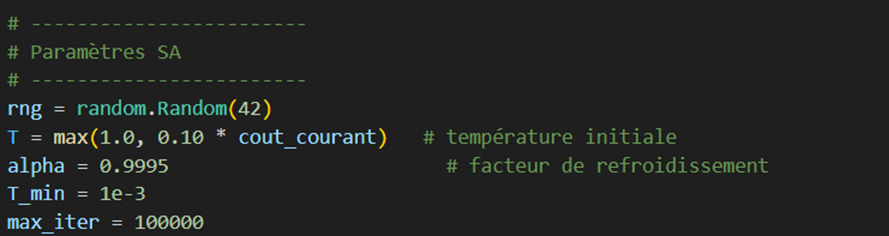

les paramètres utilisés pour l’algorithme de recuit simulé. 

La température initiale T est définie en fonction du coût courant. 

Le facteur de refroidissement alpha = 0,9995 indique une décroissance lente de la température, ce qui laisse davantage de temps à l’algorithme pour explorer de nombreuses solutions. 

La température minimale T_min et le nombre maximal d’itérations max_iter fixent les limites de l’exécution. Ces paramètres influencent directement la qualité de l’exploration et la diversité des solutions obtenues.

<u>Sans contraintes</u>
 
 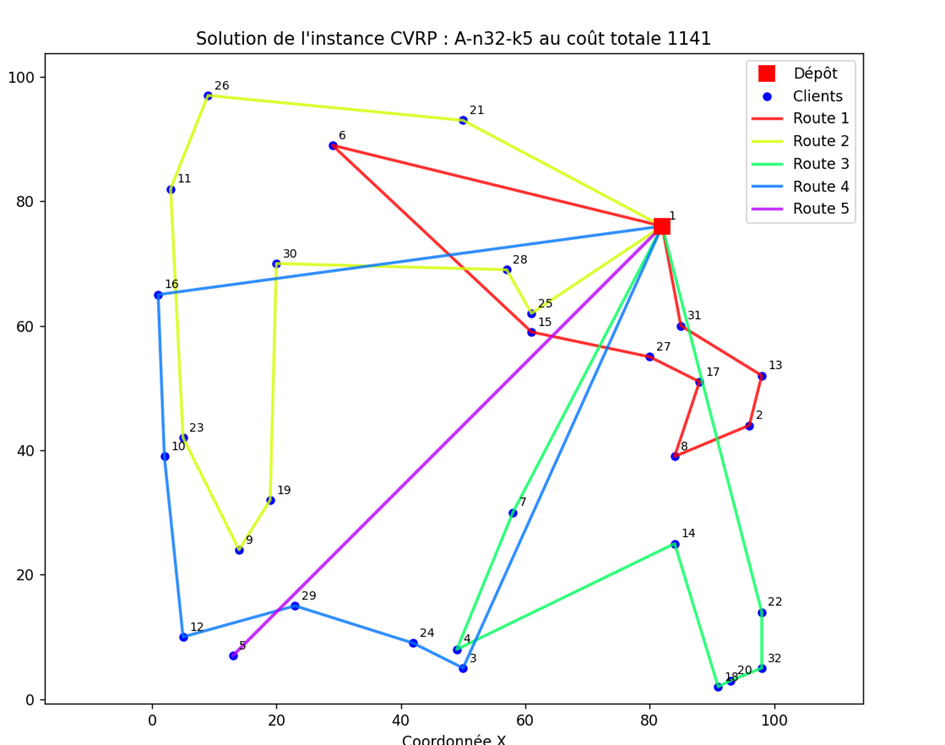

Ce graphe représente l’évolution de la solution au fil des itérations dans un cas sans contraintes. 

Dans cette configuration, la seule règle imposée consiste à respecter une charge maximale strictement inférieure à 100 pour chaque camion. 

L’algorithme doit donc organiser les tournées de manière que, pour tous les points de livraison visités, aucun camion ne dépasse cette limite de charge. 

Le graphique illustre les différents points de livraison affectés aux camions au cours des itérations du recuit simulé. Au début du processus, la solution initiale n’est généralement pas optimisée : les points peuvent être mal répartis entre les camions, ce qui peut provoquer une surcharge ou une utilisation inefficace des trajets. 

L’algorithme explore alors progressivement différentes configurations en acceptant parfois des solutions temporairement moins bonnes, ce qui explique certaines oscillations visibles sur la courbe. Au fil des itérations, la structure des tournées se stabilise. 

On observe une tendance générale à la diminution du coût, ce qui traduit l’amélioration de la qualité de la solution : les trajets deviennent plus cohérents, mieux équilibrés, et les charges de chaque camion finissent par respecter la limite imposée. Finalement, la solution obtenue par l’heuristique simple initiale présente un coût total de 1141. 

Ce résultat sert de référence, car il a été obtenu sans recours à une métaheuristique avancée.

L’objectif du recuit simulé est précisément de dépasser cette solution initiale. 

En exploitant sa capacité à explorer un grand nombre de configurations différentes, notamment grâce à son mécanisme d’acceptation probabiliste des solutions moins bonnes en début de processus, il doit être capable de produire un coût inférieur à 1141. 

Ainsi, l’enjeu pour cette métaheuristique est de prouver sa pertinence en trouvant une solution plus performante que celle générée par l’heuristique simple
 

 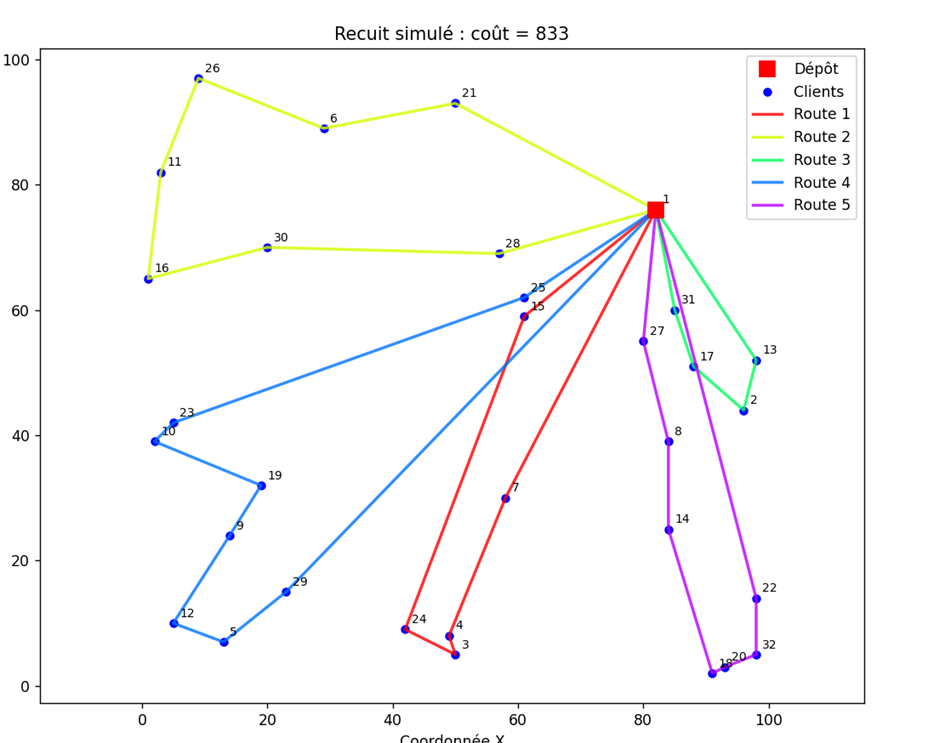<br>

Au départ, la solution initiale est souvent déséquilibrée : certains camions peuvent recevoir trop de points de livraison, d’autres trop peu, et il est possible que la charge maximale soit dépassée. L’algorithme procède alors à différentes réaffectations de points entre les camions. 

Cette phase d’exploration est volontairement large : le recuit simulé teste de nombreuses combinaisons différentes, parfois même moins bonnes que la précédente, ce qui lui permet de sortir de configurations défavorables. Dans cette exécution, l'exploration est particulièrement intense. L’algorithme modifie à plusieurs reprises la répartition des livraisons, ce qui entraîne des variations importantes du coût calculé. Ces ajustements successifs sont normaux dans une phase de recherche active : tant que la température est élevée, l’algorithme accepte encore des solutions de qualité variable pour examiner un grand nombre de possibilités. À mesure que les itérations avancent, l’algorithme devient plus strict. Il réaffecte alors les points de livraison de manière plus ciblée et commence à stabiliser la répartition entre les camions. Les combinaisons inefficaces sont progressivement éliminées, tandis que les solutions mieux équilibrées sont conservées. Chaque camion finit par obtenir un ensemble cohérent de points de livraison, tout en respectant la limite de charge imposée.
Le résultat obtenu dans cette exécution diffère de celui de l’image précédente, ce qui est normal dans un contexte sans contraintes fortes. Le recuit simulé explore de nombreuses organisations possibles, ce qui entraîne des résultats variés d’une exécution à l’autre. Cette diversité est un point fort essentiel de la méthode : elle permet d’obtenir plusieurs solutions valides, parmi lesquelles certaines peuvent être nettement meilleures que celles produites par l’heuristique simple ayant donné un coût de 833.
Ainsi, cette image illustre la capacité du recuit simulé à rechercher activement différentes répartitions de points entre les camions afin d’améliorer la solution et de dépasser la qualité obtenue par l’heuristique initiale.

 
 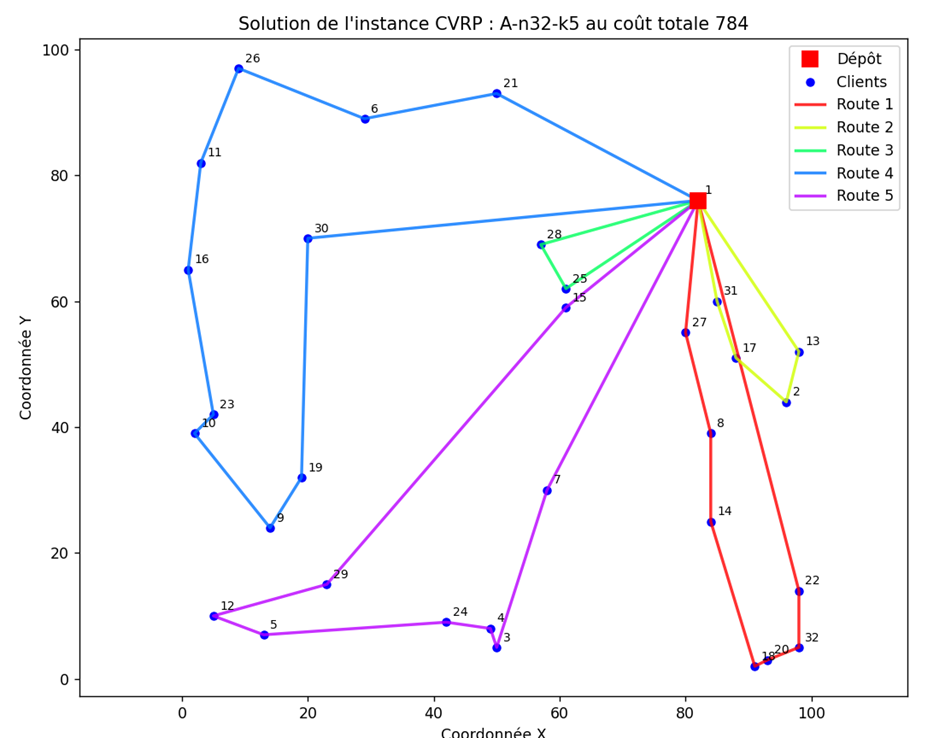<br>
Dans ce cas précis, l’algorithme est parvenu, au terme de ses itérations, à répartir les points de livraison entre les camions de façon particulièrement équilibrée. Les réaffectations successives ont permis d’éviter toute surcharge et d’obtenir une organisation efficace entre les différents camions. Le résultat final montre que la répartition trouvée respecte pleinement la contrainte de charge maximale et minimise le coût global associé à la tournée.

 
 <br>
À titre de comparaison entre la solution trouvée par l’heuristique et celle obtenue par la métaheuristique, on observe une différence significative de 5,85 %. Cette valeur ne respecte pas la contrainte que nous nous étions fixés, à savoir un écart (gap) inférieur à 5 %. Autrement dit, la métaheuristique ne parvient pas ici à améliorer suffisamment la solution de référence, ce qui remet en question la validation de cette solution au regard du critère de performance imposé.
Version avec contraintes



 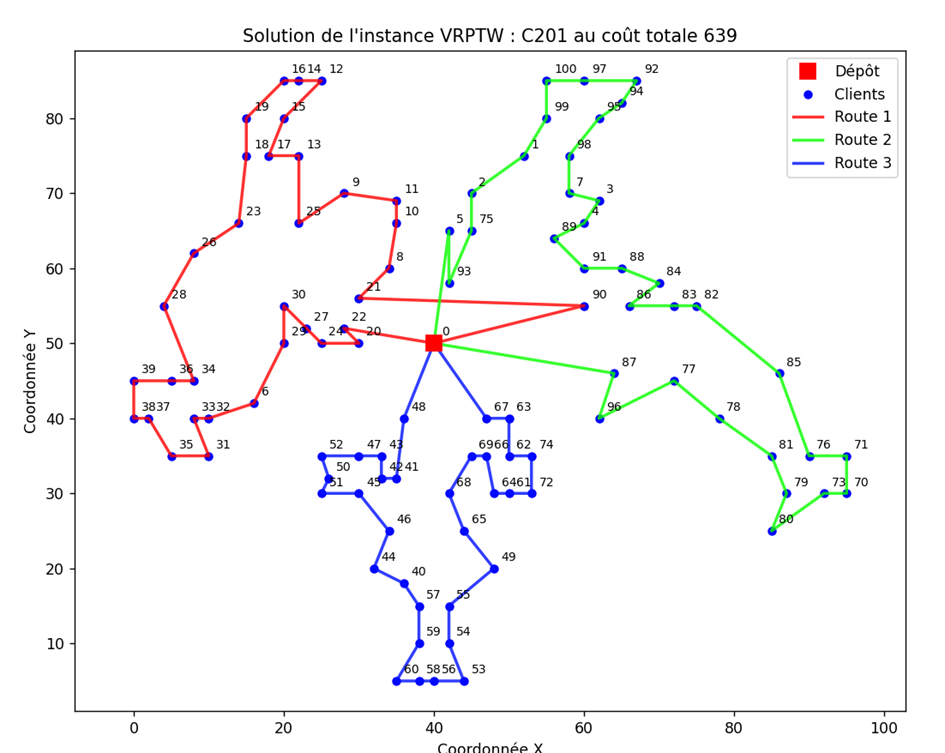<br>
Ce graphe présente la solution obtenue par une heuristique simple dans un cas soumis à la fois à des contraintes de charge (strictement inférieure à 100 par camion) et à des contraintes de temps. L’heuristique se contente ici d’établir une répartition des points de livraison qui respecte ces contraintes, sans effectuer de réelle exploration de solutions alternatives. Le résultat obtenu affiche un coût total de 639. Cette valeur est plus élevée que celle obtenue dans les cas sans contraintes, ce qui s’explique par la rigidité imposée par les limites de charge et de temps. L’heuristique produit donc une solution admissible, mais loin d’être optimale. 
Cette solution sert de référence : la métaheuristique devra impérativement obtenir un coût inférieur à 639 pour démontrer sa capacité d’amélioration.

 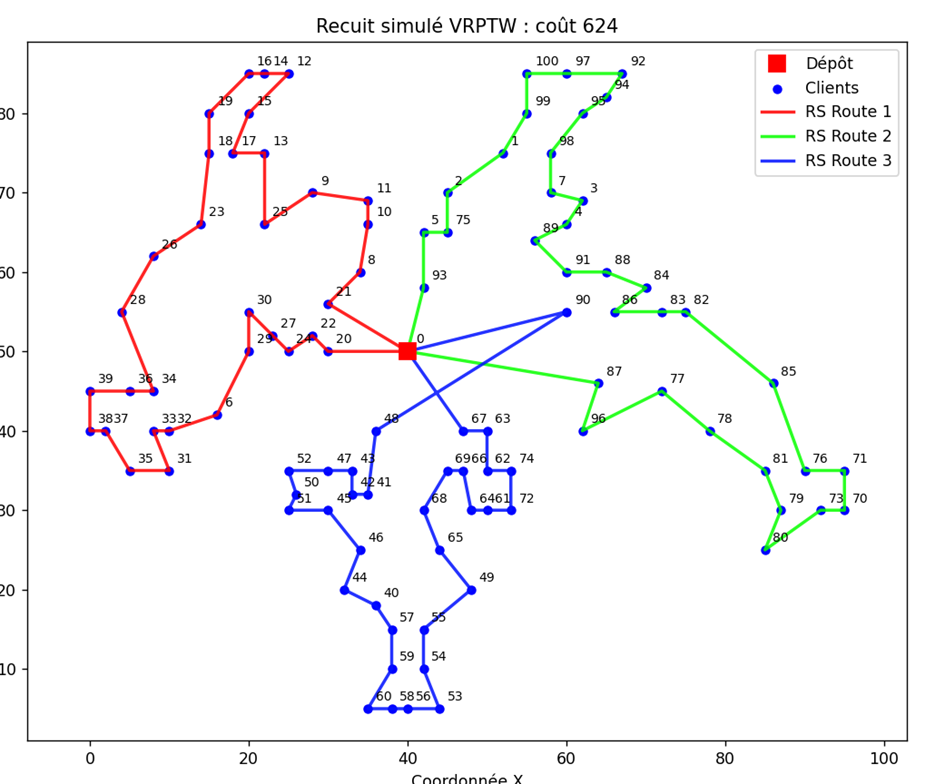<br>
Ce graphe représente la solution obtenue par le recuit simulé dans un contexte soumis aux mêmes contraintes que l’heuristique simple : charge strictement inférieure à 100 pour chaque camion ainsi que des contraintes de temps. Contrairement à l’heuristique qui produit une solution rapidement sans exploration, le recuit simulé teste un plus grand nombre de répartitions des clients entre les camions, ce qui lui permet d’améliorer progressivement la qualité de la solution. Le recuit simulé parvient ici à obtenir un coût total de 624, inférieur au coût de 639 fourni par l’heuristique simple. Cette amélioration est rendue possible grâce à sa capacité à explorer plusieurs organisations différentes des livraisons tout en respectant les contraintes imposées.
 Ce résultat montre donc l’intérêt de la métaheuristique, qui réussit à dépasser la solution initiale produite par l’heuristique simple malgré les fortes contraintes du problème.

Voici le temps d'execution que nous avons vérifier pour obtenir le résultat du coût finale pour un VRPTW avec recuit simulé :

<center><img src="images/temps_recuit.jpg" width="600"></center>

 
 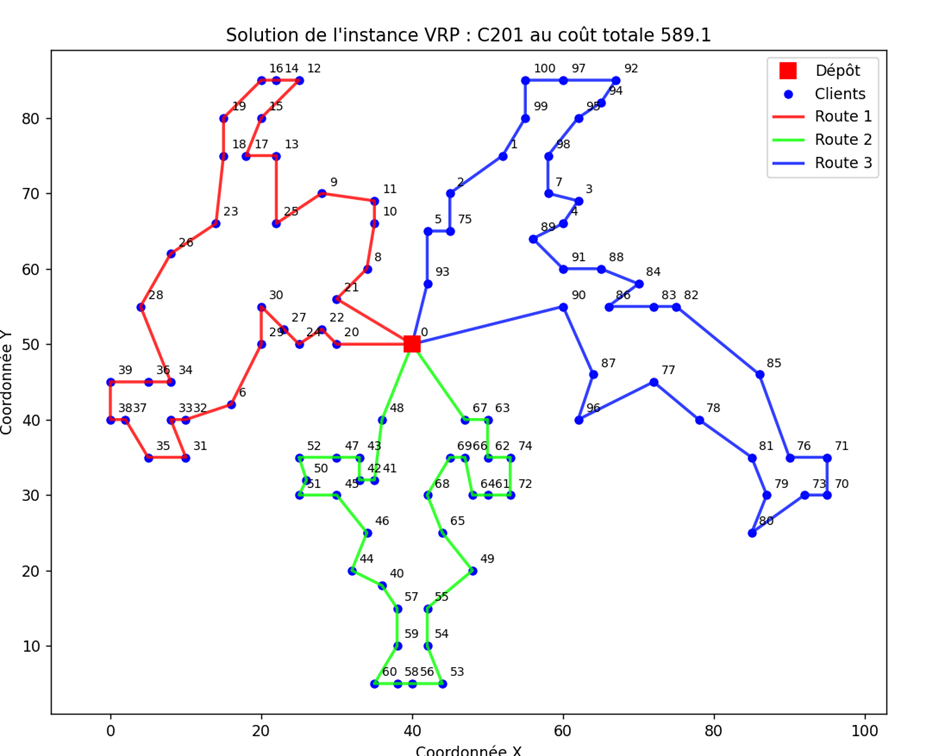<br>
Cette image présente la solution optimale obtenue pour cette instance du VRP avec contraintes de temps. L’algorithme utilisé ici parvient à organiser les livraisons entre les camions de manière à respecter simultanément la limite stricte de charge i et les différentes contraintes temporelles imposées par le problème. Malgré ces restrictions, il réussit à produire une solution de coût total 589.1, qui constitue la meilleure valeur atteignable dans ce contexte.  Ce résultat représente donc une référence optimale : aucune autre méthode ne pourra obtenir un coût inférieur sur cette instance avec les mêmes contraintes. Toutes les solutions produites par des heuristiques ou des métaheuristiques seront comparées à cette valeur, puisqu’elle marque la performance maximale que l’on peut espérer dans les conditions fixées. 
Cette solution sert ainsi de borne inférieure pour analyser les écarts observés dans les autres scénarios étudiés. Ce qui nous permet de découvrir plus tard l’algorithme le plus performant pour se problème.


 
 <br>
L’écart de coût entre la solution finale obtenue et la solution optimale est de 7 %. Cette valeur respecte la limite fixée initialement, qui devait être inférieure ou égale à 7 %. La solution finale est donc considérée comme valide au regard du critère de performance retenu.
Cependant il reste encore a le comparer avec les autres algorithmes afin de terminer le plus performant.


<u>Remarque</u>


Les résultats montrent que le recuit simulé parvient à améliorer la solution initiale fournie par l’heuristique simple tout en respectant les contraintes de charge et de temps. L’écart final reste dans la limite de 7 %, ce qui valide la qualité de la solution obtenue. Toutefois, comme cette méthode repose sur des mécanismes probabilistes, il reste à déterminer si elle constitue réellement la meilleure approche pour ce type de problème. Des comparaisons avec d’autres métaheuristiques ou optimisations exactes seraient nécessaires pour confirmer son efficacité de manière plus générale.


### c. Resultats avec ALNS

Voici les résultats obtenue avec l'ALNS :

In [ ]:
python
max_iterations = 500           # Nombre d'itérations
destruction_rate = 0.3          # 30% des clients détruits (CVRP)
destruction_rate = 0.25         # 25% des clients détruits (VRPTW)
segment_size = 100              # Mise à jour des poids tous les 100 itérations
cooling_rate = 0.99975          # Taux de refroidissement


## Personnalisation

### Modifier les paramètres ALNS

python
results = alns.run(
    max_iterations=10000,        # Plus d'itérations
    destruction_rate=0.4,        # Plus agressif
    segment_size=50,             # Mise à jour plus fréquente
    initial_temp=1000            # Température personnalisée
)

<b>Tester d'autres instances</b>

In [ ]:
*Pour CVRP* :
python
path_file_instance_vrplib = 'tests/data/A-n32-k5.vrp'
path_file_solution_vrplib = 'tests/data/A-n32-k5.sol'


*Pour VRPTW* :
python
path_file_instance_vrplib = 'tests/data/cvrplib/Vrp-Set-Solomon/C101.txt'
path_file_solution_vrplib = 'tests/data/cvrplib/Vrp-Set-Solomon/C101.sol'

<u><b>Interprétation des Résultats</b></u>

<b>Gap</b>


Gap = ((Coût_ALNS - Coût_Optimal) / Coût_Optimal) × 100


- *< 1%* : Excellent
- *1-3%* : Très bon
- *3-5%* : Bon (objectif atteint)
- *> 5%* : À améliorer

<b>Graphiques</b>

1. *Convergence* : Montre l'évolution du coût au fil des itérations
   - Courbe bleue : coût actuel (fluctuations normales)
   - Courbe rouge : meilleur coût (toujours décroissant)

<center><img src="images/convergence_vrptw_alns.png" width="1000"></center>


2. *Solution* : Visualisation des routes
   - Carré rouge : dépôt
   - Cercles bleus : clients
   - Couleurs : routes différentes

<center><img src="images/solution initial.png" width="1000"></center>


<center><img src="images/solution_vrptw_alns.png" width="1000"></center>


3. *Performance* :
   - Barres : Comparaison Initial/ALNS/Optimal
   - Courbe : Amélioration au fil du temps

<center><img src="images/performance_vrptw_alns.png" width="1000"></center>


4. *Statistiques* (VRPTW uniquement) :
   - Distribution des temps
   - Convergence logarithmique
   - Évolution du Gap
   - Tableau récapitulatif


<u><b>Métriques de Performance</b></u>

<b>VRPTW (C201)</b>

| Métrique | Valeur Typique |
|----------|----------------|
| Optimum | 591.56 |
| Solution Initiale | ~650-700 |
| Solution ALNS | ~600-620 |
| Gap | 2-4% |
| Amélioration | 10-15% |
| Temps | 40-80s |

<b>Analyse Statistique</b>

1. *Box plots* : Distribution des gaps, temps, améliorations
2. *Convergence moyenne* : Tendance sur plusieurs runs
3. *Tableau récapitulatif* : Statistiques clés (moyenne ± std)

*Interprétation* :
- Faible écart-type = algorithme stable
- Tous les runs < 5% = objectif systématiquement atteint
- Convergence rapide = bon tuning des paramètres


<center><img src="images/conclusion_algo_alns.jpg" width="600"></center>

<b>Temps d'execution</b>

<center><img src="images/temps_alns.png" width="600"></center>

### d. Interpretation des resultats

<u><b>En fonction des résultats obtenue pour un même jeu de donnée, nous avons</b></u> :
- Recherche Tabou : coût à 639, gap à 8% et temps d'execution à 9.84s
- Recuit simulé : coût 624, gap 5,41% et temps d'execution à 0.6s
- ALNS : coût 588, 0.43% et temps d'execution à 506.83s

<u><b>Avantage et inconvénient de chaque algorithme</b></u> :

Qualité de la solution trouvé :
- <b>Recuit simulé</b> : Bon (probabilité)
- <b>Recuit Taboue</b> : Très bon (mémoire)
- <b>Algorithme ALNS</b> : Meilleure (voisinage large)

Temps de traitement pour trouver la solution :
- <b>Recuit simulé</b> : Meilleure (logique simple donc itération court même si nombreux)
- <b>Recuit Taboue</b> : Bon (vérifie la mémoire)
- <b>Algorithme ALNS</b> : Lent (plusieurs opérateurs à chaque itérations)

Complexité d'implémentation :
- <b>Recuit simulé</b> : Simple (Température seule)
- <b>Recuit Taboue</b> : Assez complexe (Liste Taboue à gérer)
- <b>Algorithme ALNS</b> : Très complexe (Plusieurs opérateurs, Gestion des scores et Température)

# 10. Conclusion

Ce premier livrable permet de confirmer les préparatifs du projet en confirmant plusieurs points de réflexions qui vont déterminer le <b>temps</b> que nous prendra ce projet.

Le fait de résumer le contexte depuis le <b>cahier des charges</b> nous a permis de mieux cerner la situation que <b>l'ADEME</b> fait actuellement face. Cela nous a permis de distinguer les informations les plus utiles pour mener à bien le projet.

De ce fait, une formulation de la <b>problématique</b> a pu se faire de manière claire et concise. Ainsi, nous avons obtenu un objectif précis qui va permettre de résoudre le problème pour répondre aux besoins de l'ADEME.

Un bref rappel de quelque <b>propriété théorique</b> a permis à notre équipe de bien discerner les différents éléments scientifiques qui nous seront utile d'un point de vue technique pour mener à bien le projet sans trop de difficulté.

Nous avons alors pu réfléchir en amont à la manière dont nous allons <b>modéliser</b> le contexte d'un point de vue théorique.

Ainsi, cela nous a permis de mieux réfléchir sur le <b>choix des contraintes</b> ce qui nous va nous permettre d'avoir une simulation à la fois cohérente et réaliste pour notre future production.

Ayant alors une bonne vue d'ensemble de la manière dont nous allons modéliser les données, nous avons analyser la <b>complexité</b> de notre modélisation.

Cela nous a amenés à penser à des solutions adapter à ces complexités afin de pouvoir produire quelque chose de <b>fiable</b> et <b>optimal</b>.

Après études nous pouvons affirmer que les resultats obtenus sont capable d'apporter une amélioration au niveau de l'impact du transport sur l'environnement.


# 11. Bibliographie

Site qui explique comment implémenter des graphes et appliquer des algorithmes connues d'un point de vue informatique :
https://www.geeksforgeeks.org/dsa/graph-data-structure-and-algorithms/

Vidéo youtube qui explique l'application de l'ALNS au VRP : https://youtu.be/RfPF_4x6YG8?si=Qgxo5k9ZR7cpZErz


## Références

- *Tabu Search* : Glover, F. (1989). "Tabu Search - Part I"
- *VRP* : Toth, P., & Vigo, D. (2014). "Vehicle Routing"
- *VRPLib* : https://github.com/leonlan/VRPLIB

Livre pour expliquer la Métaheuristique <br>
https://univ.scholarvox.com/reader/docid/88818856

explication des classes de problèmes <br>
https://www.youtube.com/watch?v=g-_5OplEDbY


- *ALNS* : Ropke, S., & Pisinger, D. (2006). "An adaptive large neighborhood search heuristic for the pickup and delivery problem with time windows."
- *VRPLib* : https://github.com/leonlan/VRPLIB
- *Instances* : CVRPLIB (http://vrp.atd-lab.inf.puc-rio.br/index.php/en/)